# Fase 2 — Clusterização: Candidatos 2026 (TSE)

## Pergunta de negócio

> **Existem perfis demográfico-sociais distintos entre os candidatos, nas Eleições 2026? Combinando idade, escolaridade e patrimônio declarado, os candidatos se agrupam em segmentos claramente diferentes — e, se sim, como esses segmentos se distribuem em termos de gênero, cor/raça e estado civil?**

Para responder isso com K-Means, separamos as variáveis em dois papéis:

- **Variáveis-driver** (entram na conta de distância, definem os clusters): idade, escolaridade e patrimônio declarado.
- **Variáveis de perfil** (não entram no modelo — descrevem os clusters depois de prontos): `DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`.

> `DS_SIT_TOT_TURNO` (situação eleitoral — eleito ou não) fica de fora por enquanto: a eleição de 2026 ainda não aconteceu, então essa coluna vem toda nula nesta base. Assim que o resultado sair, vale voltar aqui e cruzar os clusters com quem foi eleito.

Essa separação importa: jogar categóricas como gênero/raça direto numa distância Euclidiana exigiria codificação cuidadosa (fora do escopo desta primeira versão). Em vez disso, os grupos nascem de 3 variáveis contínuas/ordinais bem comportadas, e o "perfil demográfico-social" completo — que é o que a pergunta pede — aparece na leitura dos clusters, não na formação deles.

**Este notebook cobre a Parte 1 (K-Means)**, em **duas rodadas de propósito**, pra mostrar por que escolha de variável e escolha de métrica importam:

1. **Versão 1**: exatamente como fizemos na primeira tentativa — escolaridade entra como o código bruto do TSE, seleção de `k` só com cotovelo + silhouette.
2. **Versão 2**: escolaridade recodificada como variável intervalar, e mais duas métricas (Davies-Bouldin, Calinski-Harabasz) apoiando a escolha de `k`.

DBSCAN, hierárquico e Bisecting K-Means serão adicionados nas próximas atualizações, reaproveitando a mesma base e a mesma pergunta.

Parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

Use os **mesmos valores** que você usou na Fase 0/1, para carregar o arquivo certo.

In [28]:
CARGO = "GOVERNADOR"   # mesmo valor usado na Fase 0/1
UF = None               # mesmo valor usado na Fase 0/1
ANO_ELEICAO = 2026

In [29]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)  # reprodutibilidade defensiva — o KMeans já usa random_state próprio,
                          # mas fixar a semente global evita surpresa se alguém adicionar
                          # outro trecho aleatório (amostragem, shuffle, etc.) mais adiante.

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_GOVERNADOR_BRASIL_2026.csv  ->  199 candidatos, 59 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,IDADE
0,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002532492,10,ALAN RICK MIRANDA,ALAN RICK,#NULO,44726570234,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,10,REPUBLICANOS,REPUBLICANOS,-1,#NULO,#NULO,#NULO,10001800116,TRABALHO DA ESPERANÇA,REPUBLICANOS / NOVO / PSD / AVANTE,AC,1976-10-23,3240992410,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,171,JORNALISTA E REDATOR,-1,#NULO,1319000.0,306686.82,162982.34,644253.0,2811645.56,0.00,5244567.72,15.472704,49
1,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002533539,36,FRANCISCO DAS CHAGAS CONCEICAO DA SILVA,DR.LUISINHO,#NULO,48432156272,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,36,AGIR,AGIR,-1,#NULO,#NULO,#NULO,10001800168,PARTIDO ISOLADO,AGIR,AC,1975-01-16,2584592402,2,MASCULINO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),3,PARDA,257,EMPRESÁRIO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,51
2,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002544015,45,SEBASTIAO BOCALOM RODRIGUES,TIÃO BOCALOM,#NULO,17357152987,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,45,PSDB,PARTIDO DA SOCIAL DEMOCRACIA BRASILEIRA,100,FEDERAÇÃO PSDB CIDADANIA,PSDB/CIDADANIA,PSDB/CIDADANIA,10001800730,PRODUZIR PARA EMPREGAR,FEDERAÇÃO RENOVAÇÃO SOLIDÁRIA(PRD/SOLIDARIEDAD...,PR,1953-05-18,2053882488,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),3,PARDA,601,AGRICULTOR,-1,#NULO,80000.0,118000.00,8000.00,0.0,0.00,1010500.00,1216500.00,14.011489,73
3,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002544107,11,MAILZA ASSIS CAMELI,MAILZA ASSIS,#NULO,61280178272,NÃO DIVULGÁVEL,-3,#NE,COLIGAÇÃO,11,PP,PROGRESSISTAS,104,FEDERAÇÃO UNIÃO PROGRESSISTA,UNIÃO/PP,UNIÃO/PP,10001800654,AVANÇA ACRE,PDT / MDB / PL / DEMOCRATA / FEDERAÇÃO UNIÃO P...,MS,1976-12-10,6765752305,4,FEMININO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,274,GOVERNADOR,-1,#NULO,0.0,0.00,0.00,0.0,0.00,167482.91,167482.91,12.028643,49
4,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AC,AC,ACRE,3,GOVERNADOR,10002549500,21,EUDO RAFFAEL LIMA DA SILVA,EUDO RAFFAEL,#NULO,79365078253,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,21,PCB,PARTIDO COMUNISTA BRASILEIRO,-1,#NULO,#NULO,#NULO,10001801047,PARTIDO ISOLADO,PCB,AC,1985-08-27,4546212402,2,MASCULINO,7,SUPERIOR INCOMPLETO,1,SOLTEIRO(A),3,PARDA,395,BANCÁRIO E ECONOMIÁRIO,-1,#NULO,165000.0,0.00,0.00,0.0,0.00,0.00,165000.00,12.013707,41


---
# Versão 1 — a primeira tentativa

Variáveis-driver: `IDADE`, `CD_GRAU_INSTRUCAO` (código bruto do TSE, 2 a 8), `Total_Bens_Log`. Escolha de `k` só com cotovelo (WCSS) + silhouette.

### V1.1) Outliers e padronização

In [30]:
colunas_driver_v1 = ['IDADE', 'CD_GRAU_INSTRUCAO', 'Total_Bens_Log']

antes = df.shape[0]
Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster_v1 = df[df['Total_Bens_Log'] <= limite_superior].copy()
print(f"Removidos {antes - df_cluster_v1.shape[0]} candidatos com patrimônio extremo "
      f"(Total_Bens_Log > {limite_superior:.2f}, ~R$ {np.expm1(limite_superior):,.0f})")
print(f"Base para clusterização: {df_cluster_v1.shape[0]} candidatos")

scaler_v1 = MinMaxScaler()
X_v1 = scaler_v1.fit_transform(df_cluster_v1[colunas_driver_v1])

df_cluster_v1[colunas_driver_v1].describe()

Removidos 1 candidatos com patrimônio extremo (Total_Bens_Log > 19.64, ~R$ 337,268,197)
Base para clusterização: 198 candidatos


,IDADE,CD_GRAU_INSTRUCAO,Total_Bens_Log
count,198.000000,198.000000,198.000000
mean,50.560606,7.585859,10.870933
std,11.550984,0.929058,5.643535
min,30.000000,3.000000,0.000000
25%,41.000000,8.000000,10.839208
50%,50.000000,8.000000,13.157671
75%,59.000000,8.000000,14.346934
max,74.000000,8.000000,18.590202


### V1.2) Escolhendo k (cotovelo + silhouette)

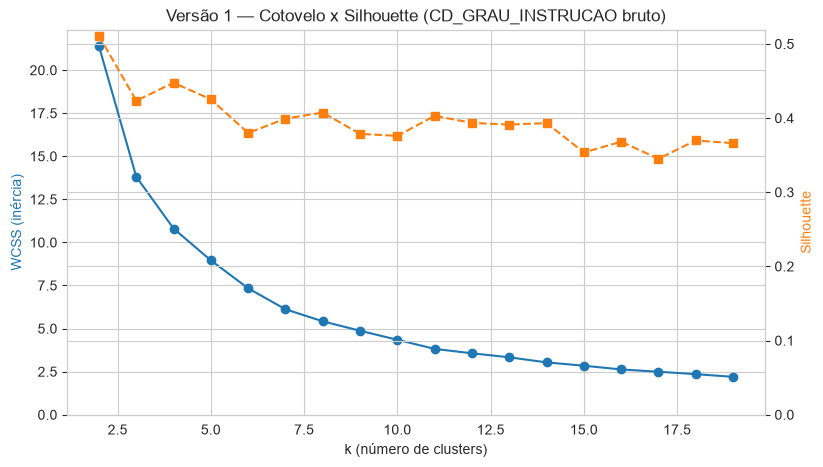

k=2  WCSS=21.388  silhouette=0.511
k=3  WCSS=13.809  silhouette=0.423
k=4  WCSS=10.806  silhouette=0.448
k=5  WCSS=8.956  silhouette=0.425
k=6  WCSS=7.335  silhouette=0.380
k=7  WCSS=6.119  silhouette=0.399
k=8  WCSS=5.419  silhouette=0.407
k=9  WCSS=4.872  silhouette=0.379
k=10  WCSS=4.348  silhouette=0.376
k=11  WCSS=3.819  silhouette=0.403
k=12  WCSS=3.564  silhouette=0.393
k=13  WCSS=3.330  silhouette=0.391
k=14  WCSS=3.036  silhouette=0.393
k=15  WCSS=2.842  silhouette=0.354
k=16  WCSS=2.626  silhouette=0.368
k=17  WCSS=2.493  silhouette=0.345
k=18  WCSS=2.352  silhouette=0.370
k=19  WCSS=2.197  silhouette=0.366


In [31]:
wcss_v1, sil_v1 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X_v1)
    wcss_v1.append(km.inertia_)
    sil_v1.append(silhouette_score(X_v1, labels))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(list(faixa_k), wcss_v1, marker='o', color='tab:blue')
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('WCSS (inércia)', color='tab:blue')
ax1.set_ylim(bottom=0)  # eixo começa em zero: um eixo cortado pode fazer o cotovelo parecer mais dramático do que é
ax1.set_title('Versão 1 — Cotovelo x Silhouette (CD_GRAU_INSTRUCAO bruto)')

ax2 = ax1.twinx()
ax2.plot(list(faixa_k), sil_v1, marker='s', linestyle='--', color='tab:orange')
ax2.set_ylabel('Silhouette', color='tab:orange')
ax2.set_ylim(bottom=min(0, min(sil_v1)))
plt.show()

for k, w, s in zip(faixa_k, wcss_v1, sil_v1):
    print(f"k={k}  WCSS={w:.3f}  silhouette={s:.3f}")

> Repare que o cotovelo não mostra uma quebra nítida — a curva desce suavemente, sem um "V" claro. Isso pode ser dado real (candidatos formando mais um contínuo do que grupos separados) ou pode ser efeito de tratar uma variável ordinal como se fosse intervalar. Seguimos mesmo assim com um `k` razoável, só pra completar a Versão 1 e comparar depois.

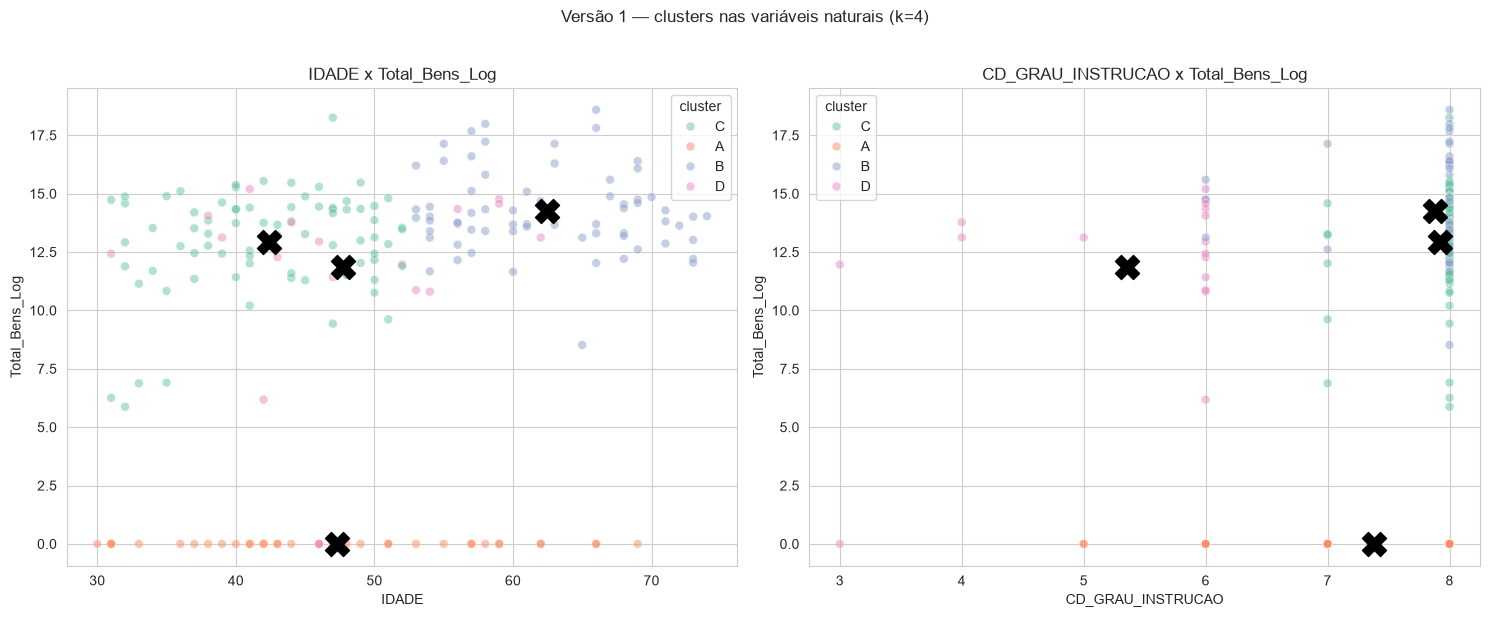

,qtd_candidatos,idade_media,instrucao_media,patrimonio_mediano
cluster,,,,
A,37,47.3,7.4,0.0
B,67,62.5,7.9,1206682.2
C,77,42.4,7.9,588097.4
D,17,47.8,5.4,420000.0


In [32]:
k_v1 = 4  # ajuste conforme a célula anterior, se quiser

kmeans_v1 = KMeans(n_clusters=k_v1, random_state=SEMENTE, n_init=10)
df_cluster_v1['cluster'] = kmeans_v1.fit_predict(X_v1)
df_cluster_v1['cluster'] = df_cluster_v1['cluster'].map(lambda x: chr(65 + x))

centroides_v1 = scaler_v1.inverse_transform(kmeans_v1.cluster_centers_)
df_centroides_v1 = pd.DataFrame(centroides_v1, columns=colunas_driver_v1)
df_centroides_v1.index = [chr(65 + i) for i in range(k_v1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_cluster_v1, x='IDADE', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[0])
axes[0].scatter(df_centroides_v1['IDADE'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[0].set_title('IDADE x Total_Bens_Log')

sns.scatterplot(data=df_cluster_v1, x='CD_GRAU_INSTRUCAO', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[1])
axes[1].scatter(df_centroides_v1['CD_GRAU_INSTRUCAO'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[1].set_title('CD_GRAU_INSTRUCAO x Total_Bens_Log')

plt.suptitle(f'Versão 1 — clusters nas variáveis naturais (k={k_v1})', y=1.02)
plt.tight_layout()
plt.show()

resumo_v1 = df_cluster_v1.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    instrucao_media=('CD_GRAU_INSTRUCAO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_v1)

---
# Versão 2 — ajustando a variável e a métrica

Dois ajustes em relação à Versão 1:

1. **Escolaridade como variável intervalar.** `CD_GRAU_INSTRUCAO` é um código **ordinal**, não intervalar: nada garante que o "salto" entre dois códigos consecutivos valha o mesmo em todos os pontos da escala (a diferença entre "lê e escreve" e "fundamental incompleto" não é comparável à diferença entre "superior incompleto" e "superior completo"). Como o K-Means calcula médias e distância Euclidiana, ele *assume* espaçamento igual — então usar o código bruto distorce essa variável. Trocamos pelo proxy padrão em pesquisa social: **anos de escolaridade equivalentes** (mesma lógica usada em censos/pesquisas domiciliares).
2. **Mais métricas para escolher `k`.** Além de WCSS e silhouette, adicionamos Davies-Bouldin e Calinski-Harabasz — quando o cotovelo é ambíguo (como foi o caso), várias métricas concordando é um sinal mais forte do que uma métrica só.

In [33]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — não dá pra estimar anos de estudo sem essa informação
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)

print("Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar):", df['ANOS_ESTUDO'].isna().sum())
df[['DS_GRAU_INSTRUCAO', 'ANOS_ESTUDO']].drop_duplicates().sort_values('ANOS_ESTUDO')

Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar): 0


,DS_GRAU_INSTRUCAO,ANOS_ESTUDO
34,ENSINO FUNDAMENTAL INCOMPLETO,4
70,ENSINO FUNDAMENTAL COMPLETO,8
24,ENSINO MÉDIO INCOMPLETO,9
12,ENSINO MÉDIO COMPLETO,11
4,SUPERIOR INCOMPLETO,13
0,SUPERIOR COMPLETO,16


> **Alternativa mais rigorosa (fora do escopo desta primeira versão):** distância de **Gower** — que trata variáveis ordinais, nominais e contínuas de forma nativa, sem forçar nenhuma delas a um espaçamento artificial — combinada com **K-Medoids/PAM** em vez de K-Means (Gower não permite calcular "média", só distância entre pontos reais). Fica como comparação futura, ao lado de DBSCAN/hierárquico/Bisecting K-Means.

### V2.1) Outliers e padronização

In [34]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

antes = df.shape[0]
df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
print(f"Removidos {antes - df_cluster.shape[0]} candidatos "
      f"(patrimônio extremo acima de ~R$ {np.expm1(limite_superior):,.0f}, ou escolaridade não divulgada)")
print(f"Base para clusterização: {df_cluster.shape[0]} candidatos")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

df_cluster[colunas_driver].describe()

Removidos 1 candidatos (patrimônio extremo acima de ~R$ 337,268,197, ou escolaridade não divulgada)
Base para clusterização: 198 candidatos


,IDADE,ANOS_ESTUDO,Total_Bens_Log
count,198.000000,198.000000,198.000000
mean,50.560606,14.959596,10.870933
std,11.550984,2.234566,5.643535
min,30.000000,4.000000,0.000000
25%,41.000000,16.000000,10.839208
50%,50.000000,16.000000,13.157671
75%,59.000000,16.000000,14.346934
max,74.000000,16.000000,18.590202


### V2.2) Escolhendo k (cotovelo + silhouette + Davies-Bouldin + Calinski-Harabasz)

- **Silhouette** (quanto maior, melhor).
- **Davies-Bouldin** (quanto **menor**, melhor): quão parecidos/sobrepostos os clusters são entre si.
- **Calinski-Harabasz** (quanto maior, melhor): razão entre dispersão entre clusters e dispersão dentro dos clusters.

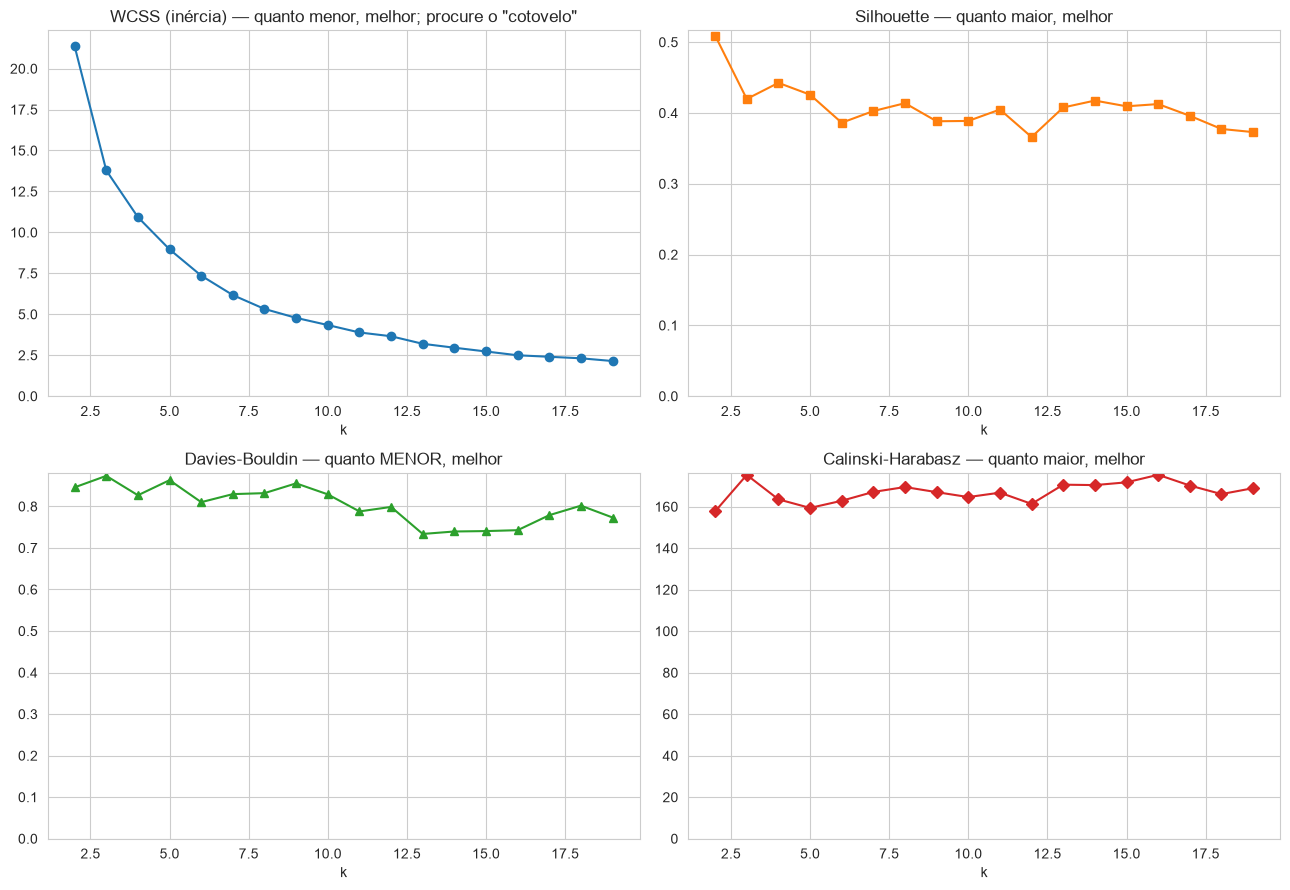

,k,wcss,silhouette,davies_bouldin,calinski_harabasz
0,2,21.368,0.509,0.846,157.725
1,3,13.784,0.420,0.874,175.278
2,4,10.929,0.443,0.827,163.507
3,5,8.962,0.426,0.863,159.369
4,6,7.359,0.386,0.810,162.823
5,7,6.171,0.403,0.830,167.085
6,8,5.325,0.414,0.832,169.438
7,9,4.780,0.388,0.856,166.978
8,10,4.343,0.389,0.829,164.610
9,11,3.889,0.405,0.788,166.729


In [35]:
wcss, sil, db, ch = [], [], [], []

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))
    ch.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(list(faixa_k), wcss, marker='o', color='tab:blue')
axes[0, 0].set_title('WCSS (inércia) — quanto menor, melhor; procure o "cotovelo"')
axes[0, 0].set_ylim(bottom=0)

axes[0, 1].plot(list(faixa_k), sil, marker='s', color='tab:orange')
axes[0, 1].set_title('Silhouette — quanto maior, melhor')
axes[0, 1].set_ylim(bottom=min(0, min(sil)))

axes[1, 0].plot(list(faixa_k), db, marker='^', color='tab:green')
axes[1, 0].set_title('Davies-Bouldin — quanto MENOR, melhor')
axes[1, 0].set_ylim(bottom=0)

axes[1, 1].plot(list(faixa_k), ch, marker='D', color='tab:red')
axes[1, 1].set_title('Calinski-Harabasz — quanto maior, melhor')
axes[1, 1].set_ylim(bottom=0)

# eixo em zero: evita que um eixo cortado exagere visualmente uma quebra que não é tão forte assim
for ax in axes.flatten():
    ax.set_xlabel('k')
    ax.grid(True)

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(faixa_k), 'wcss': wcss, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}).round(3)

### V2.3) Ajustando o K-Means

Escolha o `k` cruzando as quatro métricas acima — se elas discordarem muito, prefira o `k` mais fácil de interpretar/explicar dentro da pergunta de negócio.

In [36]:
k_final = 4  # ajuste conforme a célula anterior

kmeans = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)
df_cluster['cluster'] = df_cluster['cluster'].map(lambda x: chr(65 + x))

# Paleta única e fixa por cluster — reaproveitada em TODOS os gráficos daqui pra frente,
# pra cluster A ter sempre a mesma cor, em qualquer tipo de gráfico (scatter, barra, radar...).
clusters_ordenados = sorted(df_cluster['cluster'].unique())
cores_cluster = dict(zip(clusters_ordenados, sns.color_palette('Set2', n_colors=len(clusters_ordenados))))

df_cluster['cluster'].value_counts().sort_index()

cluster
A    18
B    76
C    66
D    38
Name: count, dtype: int64

In [37]:
resumo_driver = df_cluster.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_driver)

centroides_norm = kmeans.cluster_centers_
centroides_naturais = scaler.inverse_transform(centroides_norm)
df_centroides = pd.DataFrame(centroides_naturais, columns=colunas_driver)
df_centroides.index = [chr(65 + i) for i in range(k_final)]
df_centroides.index.name = 'cluster'
df_centroides.round(1)

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,18,49.0,10.3,459000.0
B,76,42.3,15.8,648700.7
C,66,62.4,15.8,1211591.1
D,38,47.3,14.1,0.0


,IDADE,ANOS_ESTUDO,Total_Bens_Log
cluster,,,
A,49.0,10.3,12.5
B,42.3,15.8,13.0
C,62.4,15.8,14.3
D,47.3,14.1,0.0


### Radar: todos os clusters juntos, e depois um a um

Primeiro, todos os clusters sobrepostos no mesmo radar — bom pra comparar formatos de relance. Logo abaixo, o mesmo radar **separado por cluster** — mais fácil de ler o formato de cada um sem o excesso de linhas sobrepostas. As duas versões usam os centróides **na escala padronizada (0 a 1)**, que é o que torna os 3 eixos comparáveis entre si.

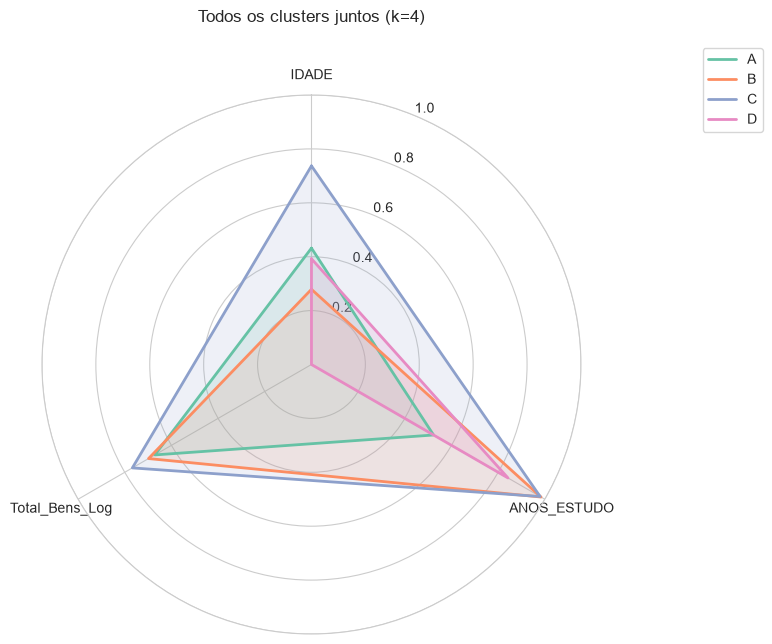

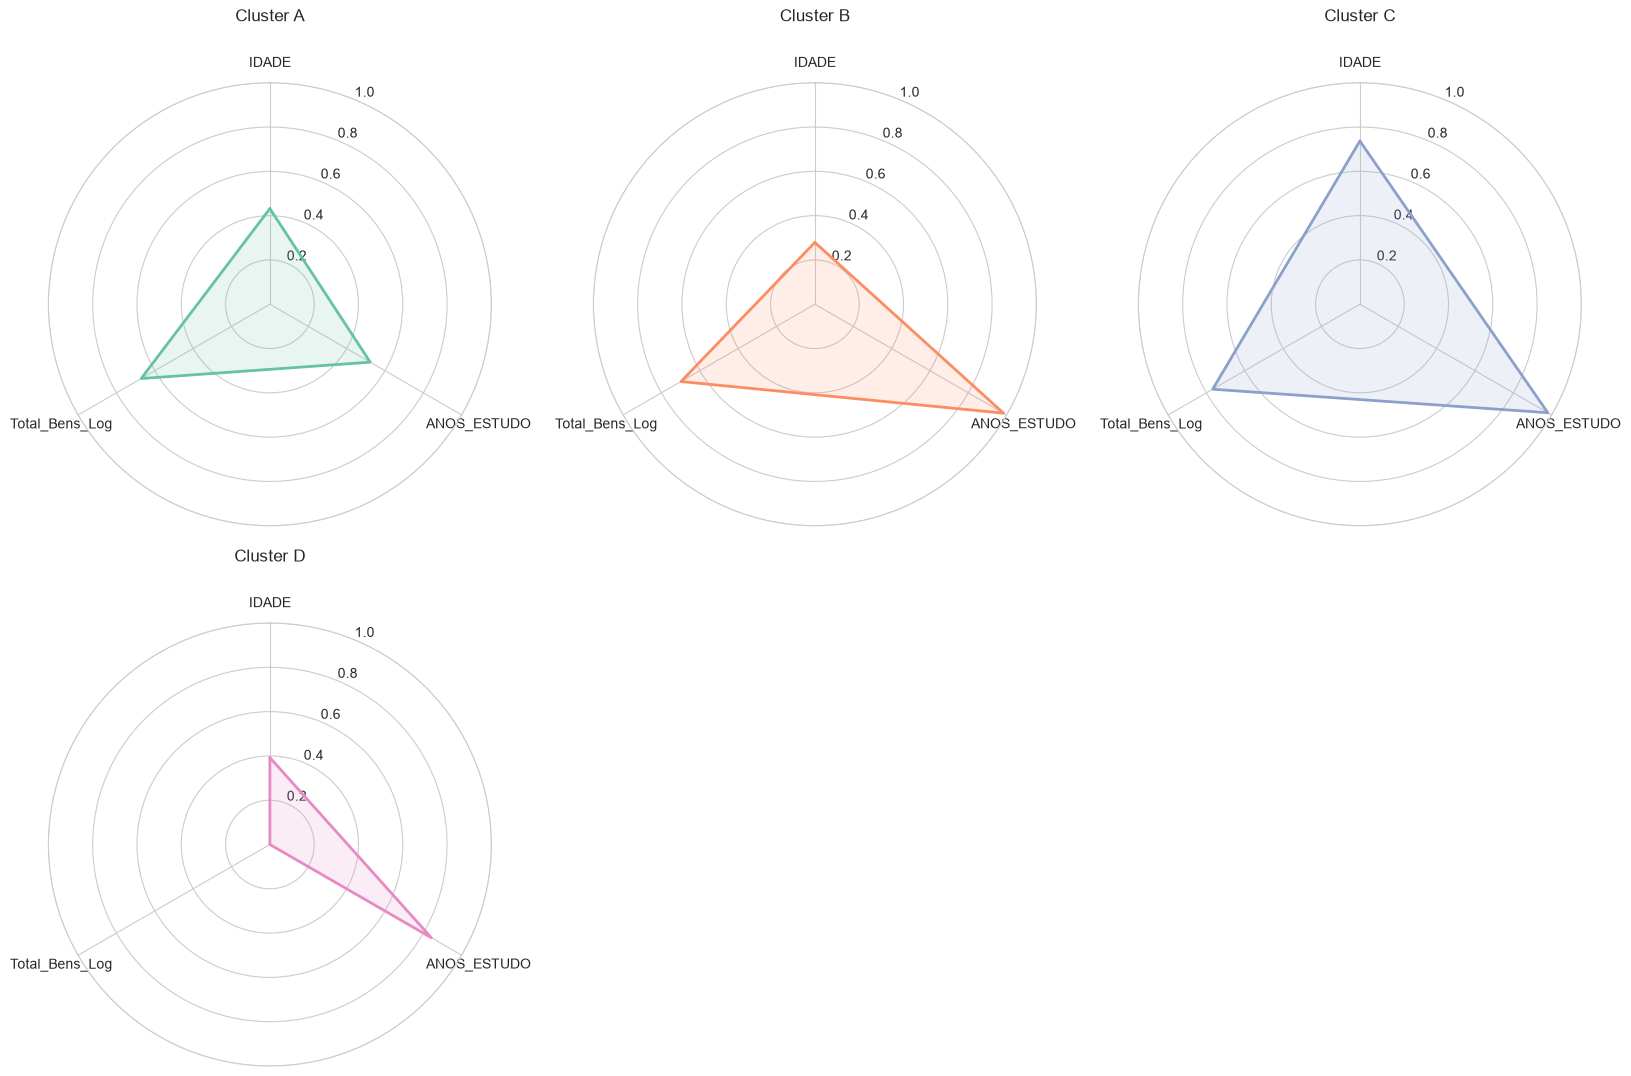

In [38]:
from math import pi

def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)
    ax.set_ylim(0, 1)

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2, label=labels_series[i], color=cor)
        ax.fill(angulos, valores, alpha=0.15, color=cor)

    ax.set_title(titulo, y=1.12)

# --- todos juntos ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm, colunas_driver, clusters_ordenados, cores_cluster,
           f'Todos os clusters juntos (k={k_final})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

# --- um radar por cluster ---
ncols = min(k_final, 3)
nrows = -(-k_final // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten() if k_final > 1 else [axes]

for i, cl in enumerate(clusters_ordenados):
    plot_radar(axes[i], [centroides_norm[i]], colunas_driver, [cl], cores_cluster, f'Cluster {cl}')

for j in range(len(clusters_ordenados), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

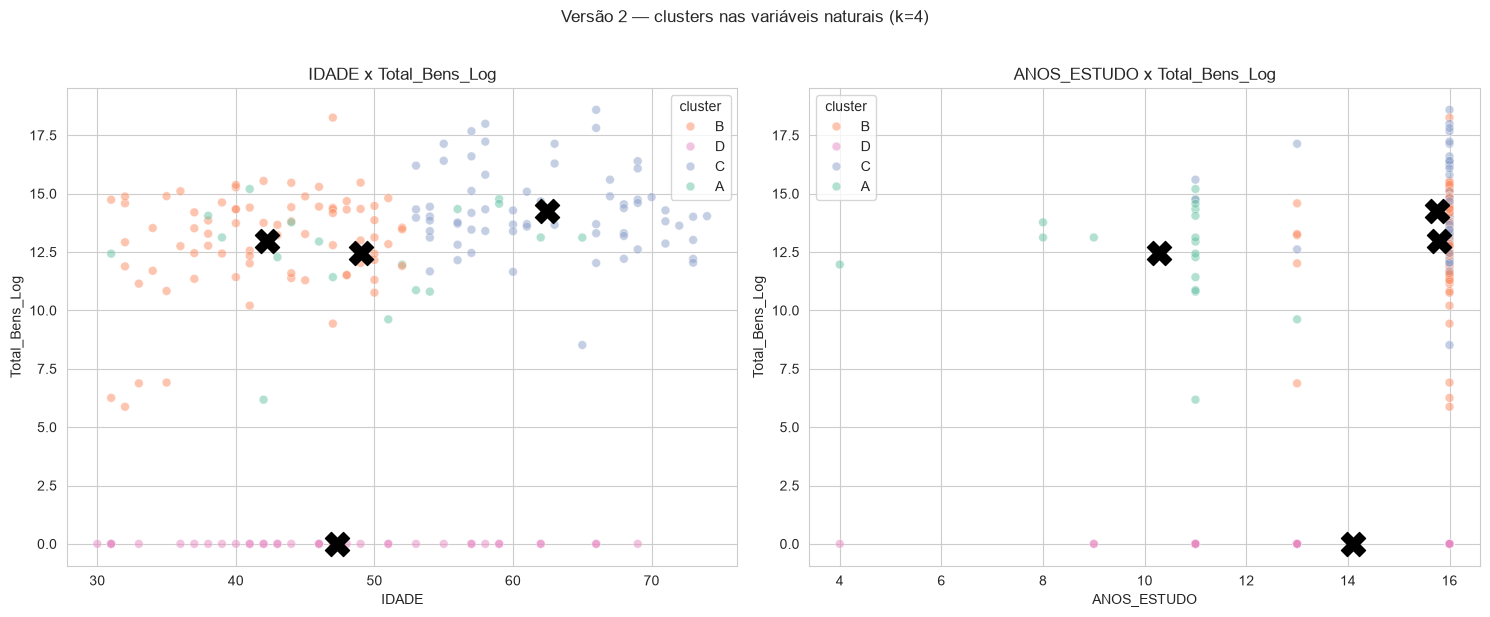

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_cluster, x='IDADE', y='Total_Bens_Log', hue='cluster', palette=cores_cluster, alpha=0.5, s=40, ax=axes[0])
axes[0].scatter(df_centroides['IDADE'], df_centroides['Total_Bens_Log'], marker='X', s=300, c='black')
axes[0].set_title('IDADE x Total_Bens_Log')

sns.scatterplot(data=df_cluster, x='ANOS_ESTUDO', y='Total_Bens_Log', hue='cluster', palette=cores_cluster, alpha=0.5, s=40, ax=axes[1])
axes[1].scatter(df_centroides['ANOS_ESTUDO'], df_centroides['Total_Bens_Log'], marker='X', s=300, c='black')
axes[1].set_title('ANOS_ESTUDO x Total_Bens_Log')

plt.suptitle(f'Versão 2 — clusters nas variáveis naturais (k={k_final})', y=1.02)
plt.tight_layout()
plt.show()

---
## Comparando Versão 1 x Versão 2

Duas coisas pra olhar lado a lado: a **métrica de qualidade** (silhouette) e o **tamanho dos grupos** — se a distribuição de candidatos por cluster mudou bastante, é sinal de que a troca de variável/métrica realmente importou.

Versão 1 (CD_GRAU_INSTRUCAO bruto), k=4: silhouette = 0.448
Versão 2 (ANOS_ESTUDO),           k=4: silhouette = 0.443


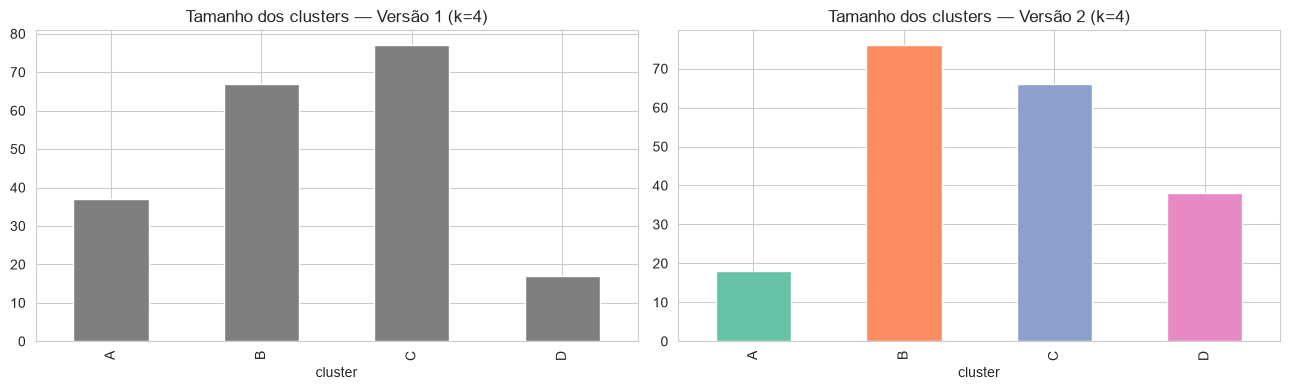

In [40]:
print(f"Versão 1 (CD_GRAU_INSTRUCAO bruto), k={k_v1}: silhouette = {sil_v1[list(faixa_k).index(k_v1)]:.3f}")
print(f"Versão 2 (ANOS_ESTUDO),           k={k_final}: silhouette = {sil[list(faixa_k).index(k_final)]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_cluster_v1['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='tab:gray')
axes[0].set_title(f'Tamanho dos clusters — Versão 1 (k={k_v1})')

contagem_v2 = df_cluster['cluster'].value_counts().sort_index()
contagem_v2.plot(kind='bar', ax=axes[1], color=[cores_cluster[c] for c in contagem_v2.index])
axes[1].set_title(f'Tamanho dos clusters — Versão 2 (k={k_final})')

plt.tight_layout()
plt.show()

---
## Perfil demográfico-social de cada cluster

A partir daqui usamos a **Versão 2** (ajustada) como resultado oficial. Primeiro pelas variáveis-driver (já visto acima), agora pelas variáveis de perfil — o que responde de fato a pergunta de negócio.

### Composição demográfica de cada cluster (variáveis de perfil)

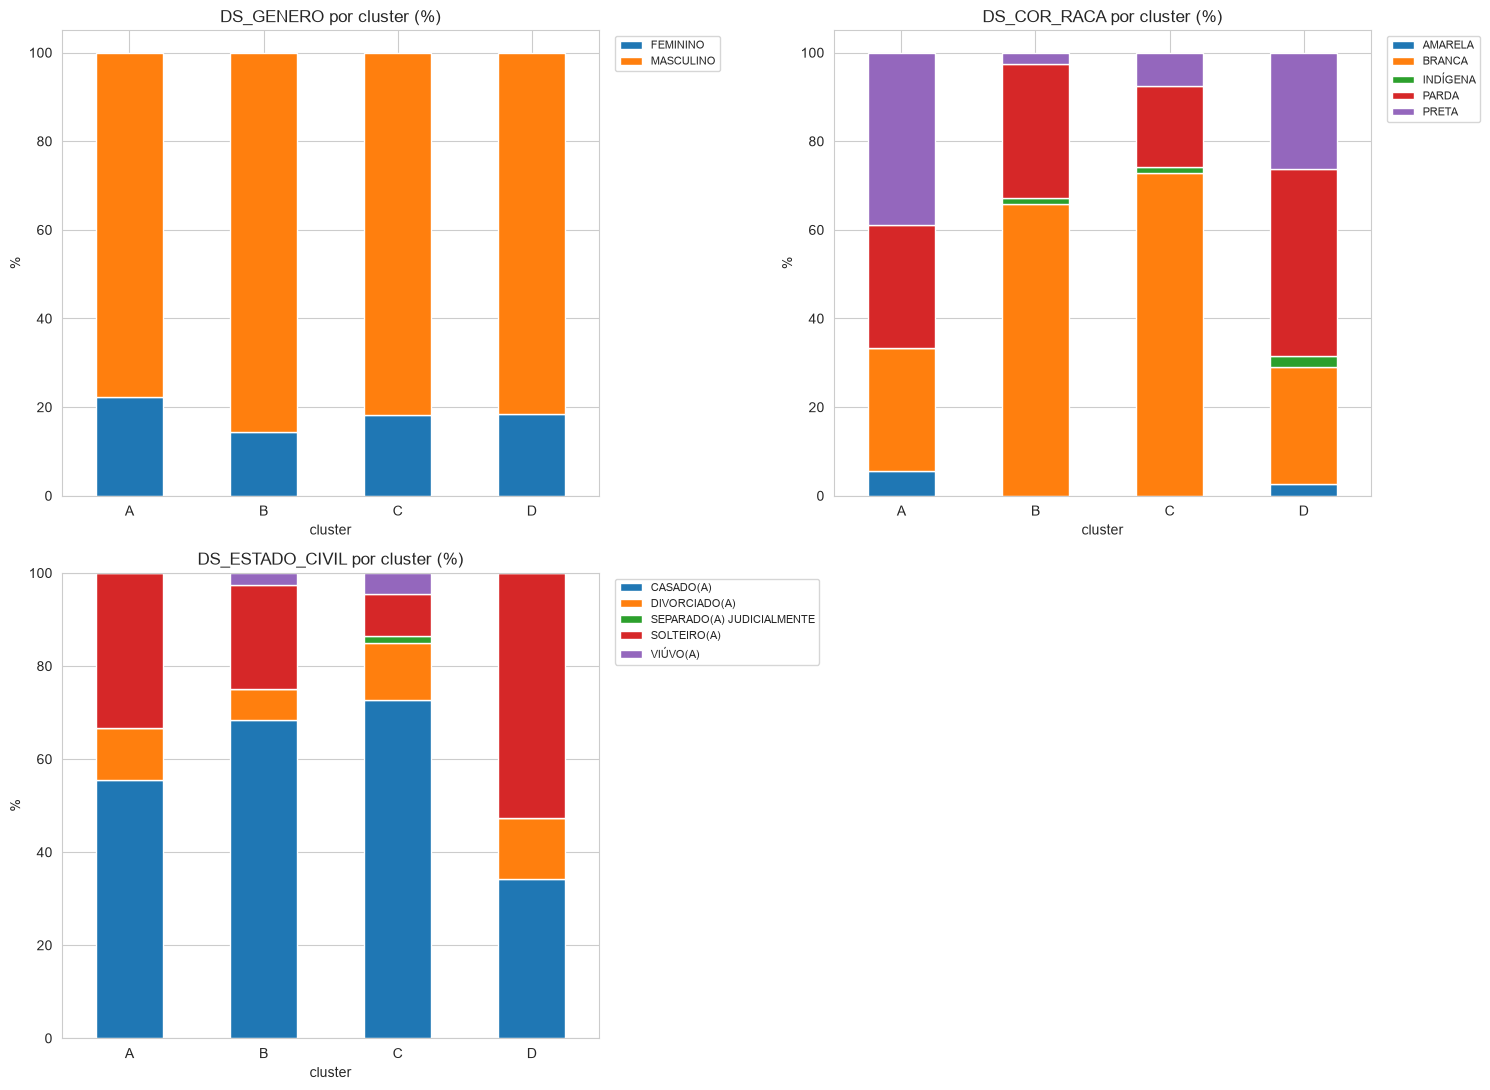

In [41]:
# DS_SIT_TOT_TURNO fica de fora por enquanto — a eleição de 2026 ainda não ocorreu,
# então essa coluna vem toda nula na base atual.
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df_cluster.columns]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    pd.crosstab(df_cluster['cluster'], df_cluster[col], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=axes[i]
    )
    axes[i].set_title(f'{col} por cluster (%)')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Pizza: a composição de cada cluster, isoladamente

As barras acima comparam os clusters entre si — é a leitura mais rigorosa quando o que importa é comparar. As pizzas abaixo mostram a mesma informação de um jeito mais familiar pra quem só quer ver "como é o cluster A por dentro", uma variável e um cluster de cada vez.

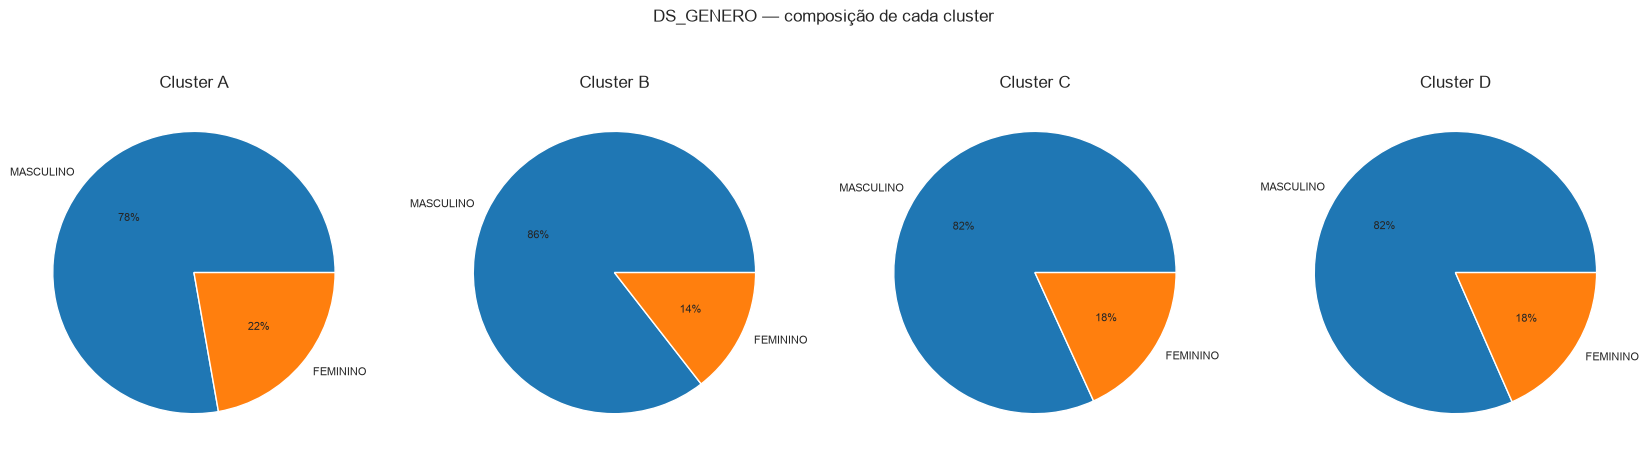

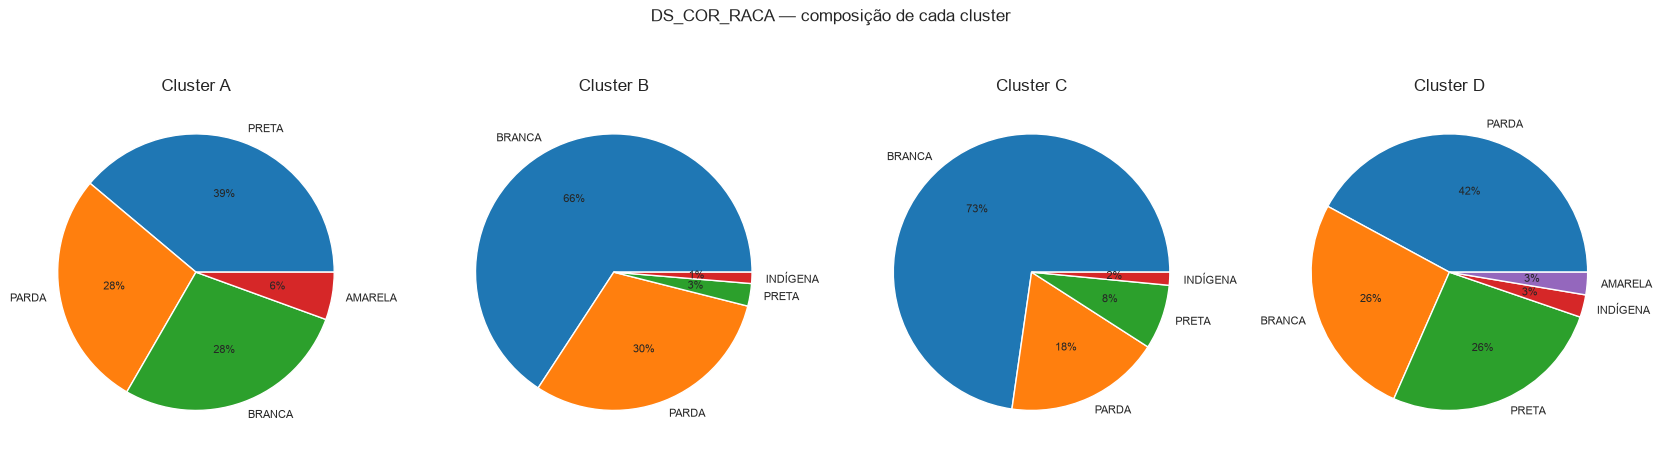

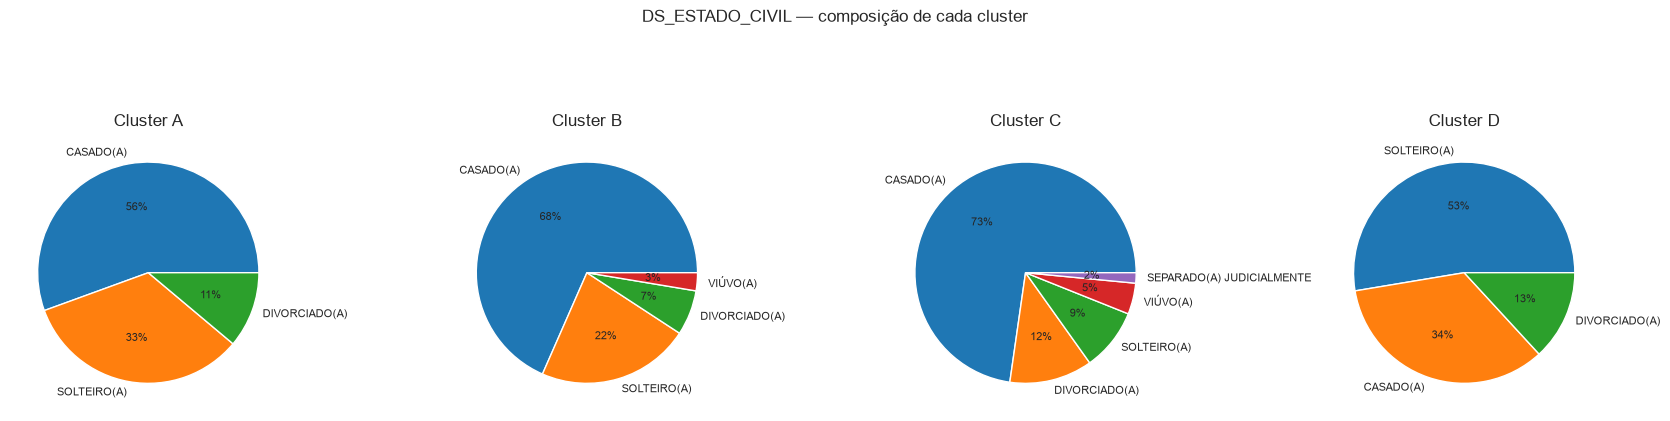

In [42]:
for col in colunas_perfil:
    fig, axes = plt.subplots(1, k_final, figsize=(4.2 * k_final, 4.5))
    if k_final == 1:
        axes = [axes]

    clusters_ordenados = sorted(df_cluster['cluster'].unique())
    for ax, cl in zip(axes, clusters_ordenados):
        contagem = df_cluster.loc[df_cluster['cluster'] == cl, col].value_counts()
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 8})
        ax.set_title(f'Cluster {cl}')

    plt.suptitle(f'{col} — composição de cada cluster', y=1.05)
    plt.tight_layout()
    plt.show()

### Direção inversa: onde cada grupo demográfico está distribuído entre os clusters

Até aqui perguntamos "dentro do cluster X, qual a composição por gênero/cor-raça/estado civil?". Agora invertemos: **de todos os candidatos de um determinado grupo (ex.: todos os do gênero masculino), em quais clusters eles estão?** É a mesma tabela de contingência, só trocando o que normaliza — por categoria demográfica em vez de por cluster.

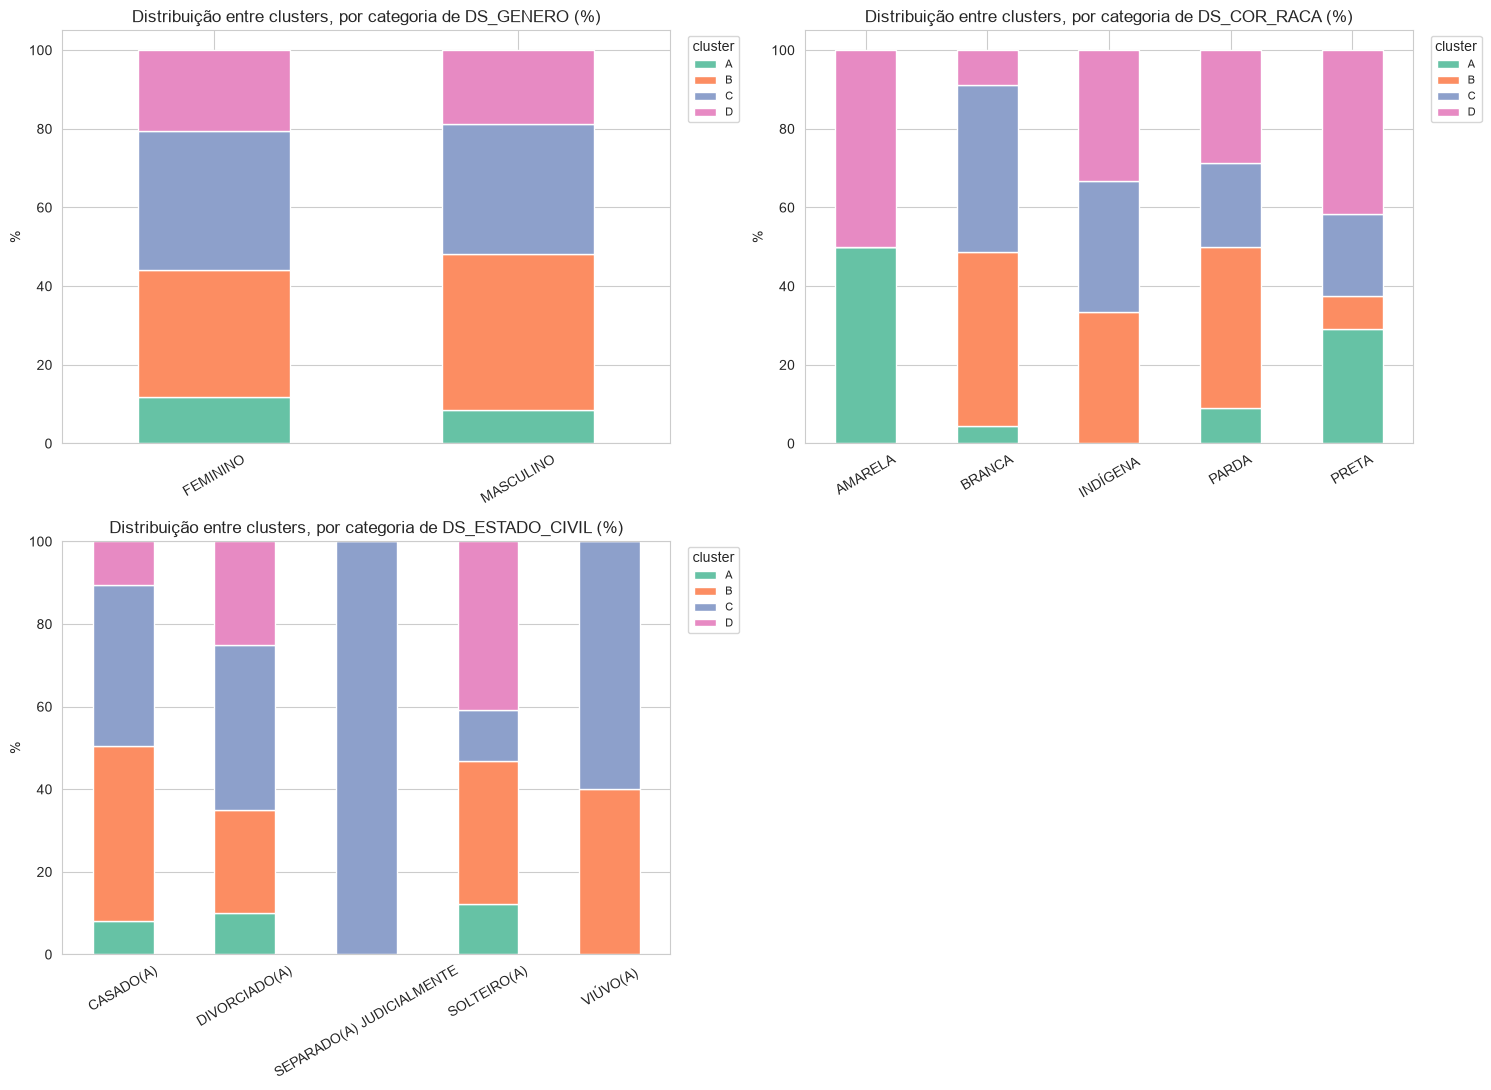

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df_cluster[col], df_cluster['cluster'], normalize='index').mul(100)
    tabela = tabela[clusters_ordenados]  # garante a mesma ordem de colunas de cores_cluster
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_cluster[c] for c in tabela.columns])
    axes[i].set_title(f'Distribuição entre clusters, por categoria de {col} (%)')
    axes[i].set_ylabel('%')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comparação por UF

Esta seção só roda na visão **Brasil** (quando `UF = None`).

In [44]:
if UF is None:
    composicao_uf = pd.crosstab(df_cluster['SG_UF'], df_cluster['cluster'], normalize='index').mul(100).round(1)
    display(composicao_uf)
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")

cluster,A,B,C,D
SG_UF,,,,
AC,0.0,66.7,16.7,16.7
AL,0.0,50.0,25.0,25.0
AM,0.0,42.9,42.9,14.3
AP,20.0,0.0,40.0,40.0
BA,28.6,28.6,42.9,0.0
CE,11.1,22.2,33.3,33.3
DF,0.0,45.5,54.5,0.0
ES,0.0,40.0,40.0,20.0
GO,16.7,16.7,66.7,0.0


---
## Respondendo à pergunta de negócio: nomeando os clusters

Esta é a etapa mais importante de toda a análise — é aqui que o K-Means (que só enxerga números) vira uma resposta que faz sentido pra gente. Três ferramentas de apoio, dos números pro nome:

1. **Ficha técnica**: uma tabela única por cluster, juntando drivers e perfil.
2. **O que destaca cada cluster**: um heatmap mostrando só o que foge da média geral — o "diferencial" de cada grupo.
3. **Rascunho automático**: um parágrafo gerado a partir da ficha técnica, pra vocês editarem em vez de escreverem do zero.

### 1) Ficha técnica por cluster

In [45]:
ficha = df_cluster.groupby('cluster').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
ficha['pct_do_total'] = (ficha['qtd'] / ficha['qtd'].sum() * 100).round(1)

for col in colunas_perfil:
    ficha[f'{col}_predominante'] = df_cluster.groupby('cluster')[col].agg(lambda s: s.mode().iat[0])
    ficha[f'{col}_pct'] = df_cluster.groupby('cluster')[col].apply(
        lambda s: (s == s.mode().iat[0]).mean() * 100
    ).round(1)

ficha

,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,pct_do_total,DS_GENERO_predominante,DS_GENERO_pct,DS_COR_RACA_predominante,DS_COR_RACA_pct,DS_ESTADO_CIVIL_predominante,DS_ESTADO_CIVIL_pct
cluster,,,,,,,,,,,
A,18,49.0,10.3,459000.0,9.1,MASCULINO,77.8,PRETA,38.9,CASADO(A),55.6
B,76,42.3,15.8,648700.7,38.4,MASCULINO,85.5,BRANCA,65.8,CASADO(A),68.4
C,66,62.4,15.8,1211591.1,33.3,MASCULINO,81.8,BRANCA,72.7,CASADO(A),72.7
D,38,47.3,14.1,0.0,19.2,MASCULINO,81.6,PARDA,42.1,SOLTEIRO(A),52.6


### 2) O que destaca cada cluster (desvio em relação à média geral)

Quanto mais forte a cor (positiva ou negativa), mais aquele cluster se afasta da média geral de candidatos naquela variável — é isso que normalmente vira o "nome" do cluster.

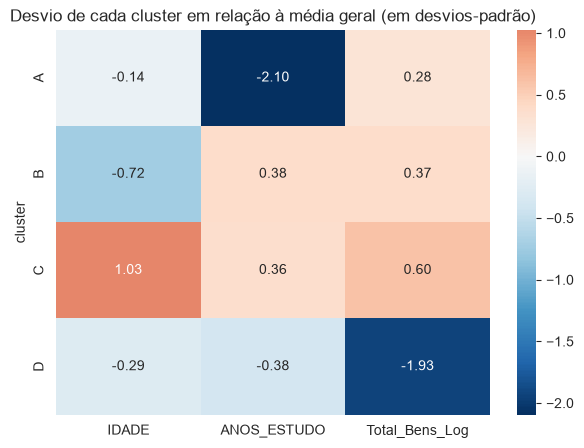

In [46]:
medias_gerais = df_cluster[colunas_driver].mean()
desvios_gerais = df_cluster[colunas_driver].std()
medias_cluster = df_cluster.groupby('cluster')[colunas_driver].mean()

zscore_cluster = (medias_cluster - medias_gerais) / desvios_gerais

plt.figure(figsize=(7, 1 + k_final))
sns.heatmap(zscore_cluster, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Desvio de cada cluster em relação à média geral (em desvios-padrão)')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()

### 3) Rascunho automático — editem à vontade

In [47]:
for cl in clusters_ordenados:
    linha = ficha.loc[cl]
    print(f"Cluster {cl}  ({linha['qtd']:.0f} candidatos, {linha['pct_do_total']:.0f}% do total)")
    print(f"  Idade média: {linha['idade_media']:.0f} anos | Escolaridade média: {linha['anos_estudo_medio']:.0f} anos de estudo "
          f"| Patrimônio mediano: R$ {linha['patrimonio_mediano']:,.0f}")
    for col in colunas_perfil:
        print(f"  Predominância em {col}: {linha[f'{col}_predominante']} ({linha[f'{col}_pct']:.0f}%)")
    print(f"  >> Nome sugerido: _______________________")
    print()

Cluster A  (18 candidatos, 9% do total)
  Idade média: 49 anos | Escolaridade média: 10 anos de estudo | Patrimônio mediano: R$ 459,000
  Predominância em DS_GENERO: MASCULINO (78%)
  Predominância em DS_COR_RACA: PRETA (39%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (56%)
  >> Nome sugerido: _______________________

Cluster B  (76 candidatos, 38% do total)
  Idade média: 42 anos | Escolaridade média: 16 anos de estudo | Patrimônio mediano: R$ 648,701
  Predominância em DS_GENERO: MASCULINO (86%)
  Predominância em DS_COR_RACA: BRANCA (66%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (68%)
  >> Nome sugerido: _______________________

Cluster C  (66 candidatos, 33% do total)
  Idade média: 62 anos | Escolaridade média: 16 anos de estudo | Patrimônio mediano: R$ 1,211,591
  Predominância em DS_GENERO: MASCULINO (82%)
  Predominância em DS_COR_RACA: BRANCA (73%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (73%)
  >> Nome sugerido: _______________________

Cluster D  (38 candidatos

### Nomes finais dos clusters (K-Means)

Preencham com base nas três ferramentas acima:

- **Cluster A:** ...
- **Cluster B:** ...
- **Cluster C:** ...
- **Cluster D:** ...

---
# Parte 2 — Bisecting K-Means

**A ideia:** em vez de escolher um `k` e rodar o K-Means uma vez, o Bisecting K-Means começa com **1 cluster (todo mundo)** e vai dividindo em 2 repetidamente — a cada passo, escolhe **um** cluster já existente e o quebra em 2, aumentando `k` em 1 de cada vez (1→2→3→4→...).

O scikit-learn tem `BisectingKMeans`, mas ele só devolve o resultado final — não expõe **qual cluster foi escolhido em cada divisão**, que é exatamente o que você quer enxergar. Por isso implementamos o algoritmo manualmente aqui: a cada passo, guardamos qual cluster foi dividido, o tamanho dele e sua inércia média, o que nos dá:

1. **A árvore de divisões** — literalmente o que você pediu para enxergar.
2. **Um critério de parada visual**: enquanto o algoritmo estiver dividindo clusters **grandes**, cada divisão ainda separa bastante gente diferente — informação nova. Quando ele passa a dividir clusters **pequenos**, é sinal de que os grupos grandes e relevantes já foram encontrados, e o que resta é só "aparar as bordas". O gráfico de tamanho por nível, abaixo, mostra exatamente esse ponto de virada.

Usamos a mesma base da Versão 2 (`X`, já padronizada e sem outliers) para ficar diretamente comparável ao K-Means.

### 1) Implementação manual, guardando o histórico de divisões

In [48]:
def bisecting_kmeans_com_historico(X, k_max, criterio='inercia', random_state=SEMENTE):
    """
    Roda o Bisecting K-Means manualmente até k_max clusters, guardando o histórico
    de cada divisão (qual cluster foi escolhido, tamanho, inércia).

    criterio:
      'tamanho'  -> a cada passo, divide o cluster com MAIS pontos
      'inercia'  -> a cada passo, divide o cluster com MAIOR inércia MÉDIA (dispersão por
                    ponto, não a soma) — assim o critério não fica enviesado pra clusters
                    grandes só por terem mais pontos somando distância. Note que isso é
                    diferente do padrão do sklearn.cluster.BisectingKMeans ('biggest_inertia'),
                    que usa a soma total: a soma tende a crescer com o tamanho do cluster
                    quase por definição, então na prática quase sempre escolhe o maior
                    cluster disponível — o que não é o que queremos aqui.
    """
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        # média por ponto (não soma) — decisivo pra o critério não virar um proxy de tamanho
        return float(((pontos - centro) ** 2).sum(axis=1).mean())

    clusters = {0: np.arange(X.shape[0])}   # cluster raiz = todos os pontos
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        if criterio == 'tamanho':
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        else:
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))

        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido, 'pai_tamanho': len(indices_pai), 'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a, 'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b, 'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico

k_max_bisecting = max(faixa_k) + 1  # mesma faixa usada no K-Means (até 20)
clusters_finais, historico_bisecting = bisecting_kmeans_com_historico(X, k_max_bisecting, criterio='inercia')

print(f"Divisões realizadas: {len(historico_bisecting)}  (de k=1 até k={k_max_bisecting})")

Divisões realizadas: 19  (de k=1 até k=20)


### 2) Quando parar? Tamanho e inércia do cluster escolhido, a cada nível

Procure o ponto em que a curva despenca — é onde o algoritmo para de dividir clusters relevantes e passa a dividir sobras.

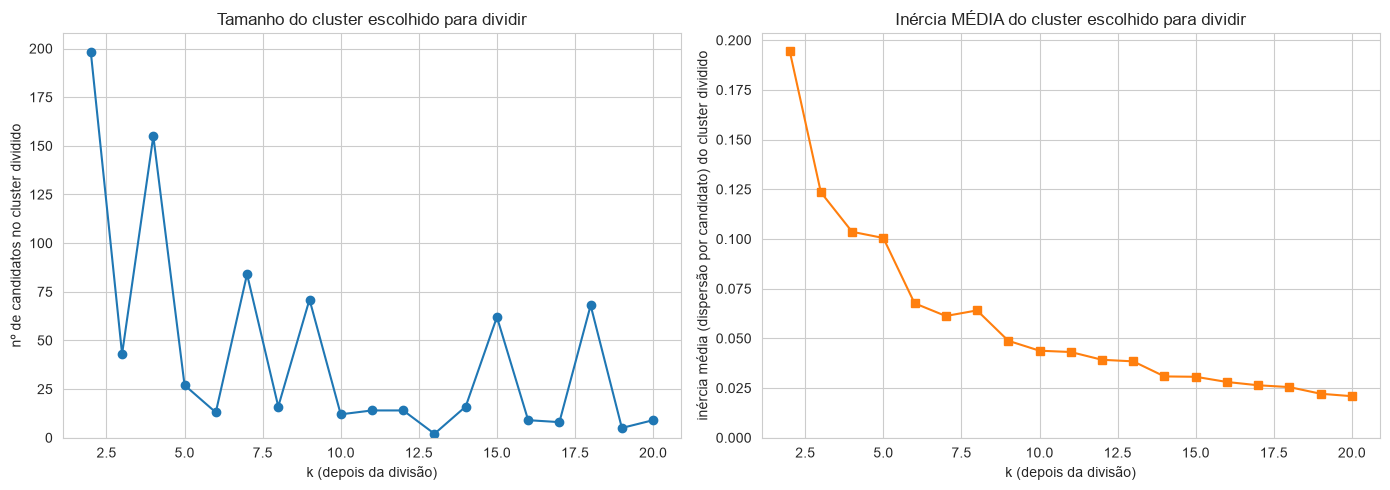

In [49]:
k_resultante = [h['k_resultante'] for h in historico_bisecting]
tamanho_escolhido = [h['pai_tamanho'] for h in historico_bisecting]
inercia_escolhida = [h['pai_inercia'] for h in historico_bisecting]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_resultante, tamanho_escolhido, marker='o')
axes[0].set_title('Tamanho do cluster escolhido para dividir')
axes[0].set_xlabel('k (depois da divisão)')
axes[0].set_ylabel('nº de candidatos no cluster dividido')
axes[0].set_ylim(bottom=0)
axes[0].grid(True)

axes[1].plot(k_resultante, inercia_escolhida, marker='s', color='tab:orange')
axes[1].set_title('Inércia MÉDIA do cluster escolhido para dividir')
axes[1].set_xlabel('k (depois da divisão)')
axes[1].set_ylabel('inércia média (dispersão por candidato) do cluster dividido')
axes[1].set_ylim(bottom=0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3) A árvore de divisões

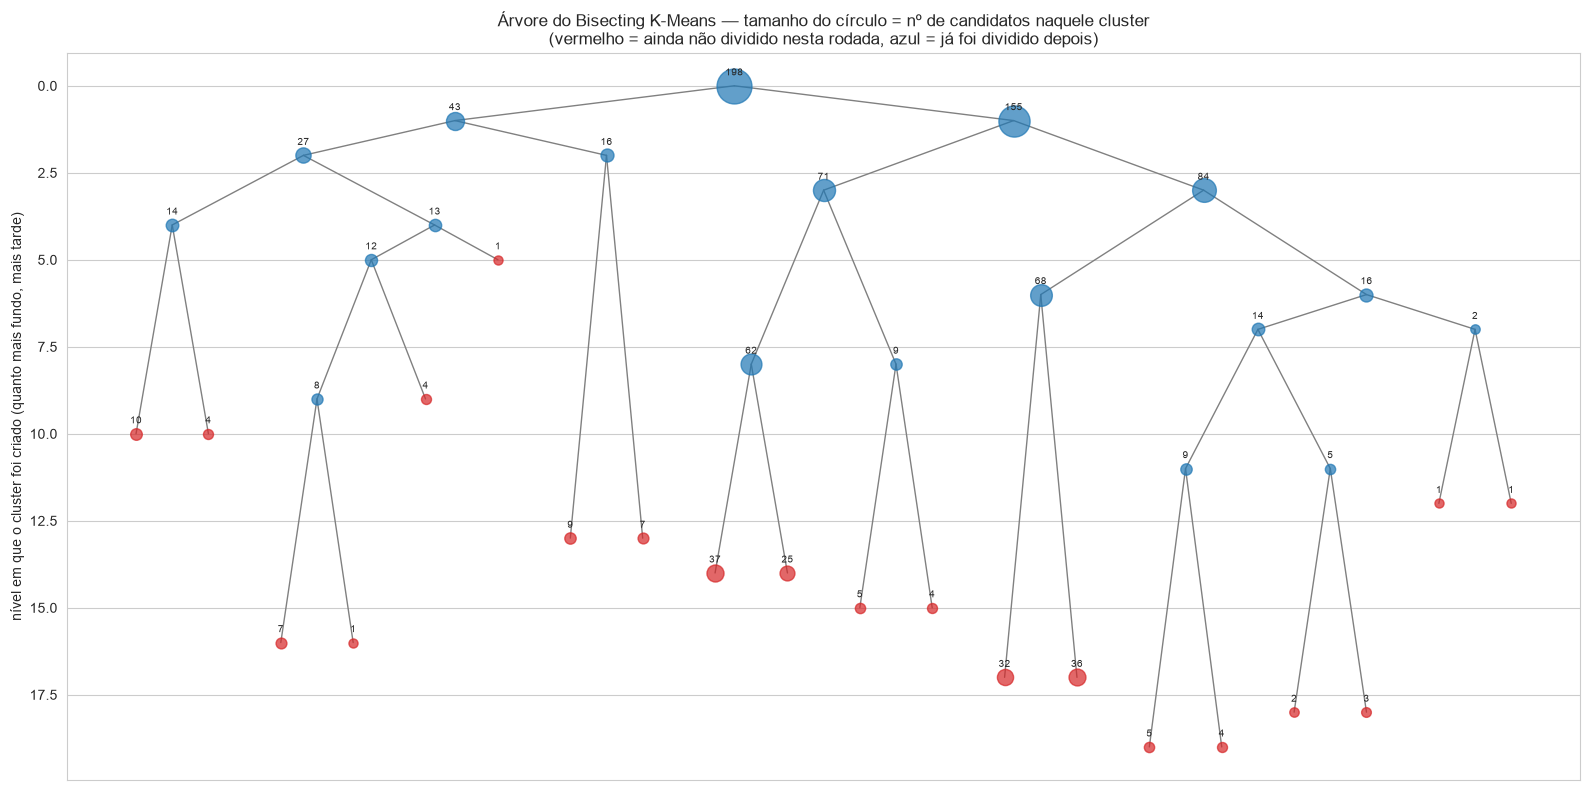

In [50]:
nos = {0: {'pai': None, 'nivel': 0, 'tamanho': X.shape[0], 'filhos': None}}
for h in historico_bisecting:
    nos[h['pai_id']]['filhos'] = [h['filho_a_id'], h['filho_b_id']]
    nos[h['filho_a_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_a_tamanho'], 'filhos': None}
    nos[h['filho_b_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_b_tamanho'], 'filhos': None}

# posição horizontal: folhas em ordem, nós internos = média dos filhos (layout clássico de árvore)
posicoes = {}
_x = [0]

def atribuir_x(no_id):
    filhos = nos[no_id]['filhos']
    if filhos is None:
        posicoes[no_id] = _x[0]
        _x[0] += 1
    else:
        for f in filhos:
            atribuir_x(f)
        posicoes[no_id] = sum(posicoes[f] for f in filhos) / len(filhos)

atribuir_x(0)

plt.figure(figsize=(16, 8))
for no_id, info in nos.items():
    if info['filhos']:
        for f in info['filhos']:
            plt.plot([posicoes[no_id], posicoes[f]], [info['nivel'], nos[f]['nivel']],
                      color='gray', linewidth=1, zorder=1)

for no_id, info in nos.items():
    e_folha = info['filhos'] is None
    plt.scatter(posicoes[no_id], info['nivel'], s=40 + info['tamanho'] * 3,
                color='tab:red' if e_folha else 'tab:blue', alpha=0.7, zorder=2)
    plt.text(posicoes[no_id], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

plt.gca().invert_yaxis()
plt.ylabel('nível em que o cluster foi criado (quanto mais fundo, mais tarde)')
plt.xticks([])
plt.title('Árvore do Bisecting K-Means — tamanho do círculo = nº de candidatos naquele cluster\n(vermelho = ainda não dividido nesta rodada, azul = já foi dividido depois)')
plt.tight_layout()
plt.show()

### 3.1) Animação: a árvore crescendo, nível a nível

A árvore estática fica poluída com muitos níveis de uma vez. Esta animação mostra **a mesma árvore**, mas revelando um nível por vez — a cada frame, um nó vermelho (folha ainda não dividida) "explode" em dois, e vira azul. As posições dos nós são as mesmas da árvore estática (calculadas uma vez só), então nada pula de lugar entre frames — só aparece o que é novo.

In [51]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

historico_por_k = {h['k_resultante']: h for h in historico_bisecting}
ks_disponiveis = list(range(1, max(historico_por_k) + 1))

def estado_arvore_no_k(k):
    """Quais nós já existem, e quais deles ainda são folha (não foram divididos), no frame k."""
    existentes = [nid for nid, info in nos.items() if info['nivel'] <= k - 1]
    set_existentes = set(existentes)
    folhas = []
    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos is None or filhos[0] not in set_existentes:
            folhas.append(nid)
    return existentes, set(folhas)

max_nivel = max(info['nivel'] for info in nos.values())
x_min, x_max = min(posicoes.values()), max(posicoes.values())

fig, ax = plt.subplots(figsize=(16, 8))

def desenhar_frame_arvore(k):
    ax.clear()
    existentes, folhas = estado_arvore_no_k(k)
    set_existentes = set(existentes)

    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos:
            for f in filhos:
                if f in set_existentes:
                    ax.plot([posicoes[nid], posicoes[f]], [nos[nid]['nivel'], nos[f]['nivel']],
                            color='gray', linewidth=1, zorder=1)

    for nid in existentes:
        info = nos[nid]
        cor = 'tab:red' if nid in folhas else 'tab:blue'
        ax.scatter(posicoes[nid], info['nivel'], s=40 + info['tamanho'] * 3, color=cor, alpha=0.7, zorder=2)
        ax.text(posicoes[nid], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

    ax.set_xlim(x_min - 1, x_max + 1)
    ax.set_ylim(max_nivel + 1, -1)  # eixo fixo e invertido (raiz no topo), sem "pulos" entre frames
    ax.set_xticks([])
    ax.set_ylabel('nível em que o cluster foi criado')
    if k in historico_por_k:
        h = historico_por_k[k]
        ax.set_title(f'Árvore do Bisecting K-Means — k={k}  (dividiu um cluster de {h["pai_tamanho"]} candidatos)')
    else:
        ax.set_title(f'Árvore do Bisecting K-Means — k={k} (estado inicial, 1 cluster só)')

anim = FuncAnimation(fig, desenhar_frame_arvore, frames=ks_disponiveis, interval=800, repeat=True)
plt.close(fig)  # evita mostrar também uma figura estática duplicada, além da animação
HTML(anim.to_jshtml())

> Se a animação demorar pra renderizar (muitos frames), aumente `interval` (ela roda mais devagar) ou reduza `k_max_bisecting` mais acima. Pra usar fora do notebook (ex.: num slide): `anim.save('arvore_bisecting.gif', writer='pillow')`.

### 4) Explorando diferentes k, na prática

Antes de fechar num único `k`, vale ver como os clusters realmente mudam à medida que o Bisecting K-Means continua dividindo — os dois gráficos anteriores (tamanho/inércia por nível, e a árvore) só sugerem isso de forma indireta. Reconstruímos a partição em `k=2, 3, 4` e `5`, mostrando a ficha resumida e o radar (reaproveitando a mesma `plot_radar` da Parte 1) de cada uma.

Como o Bisecting K-Means não calcula um centróide final único (ele só guarda os centros de cada divisão de 2 em 2, não da partição completa em k clusters), usamos a média das variáveis-driver padronizadas dentro de cada cluster como "centróide de fato" para o radar — mesma ideia de sempre.


--- Bisecting K-Means, k=2 ---


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,155,51.9,15.2,900000.0
B,43,45.8,14.1,0.0


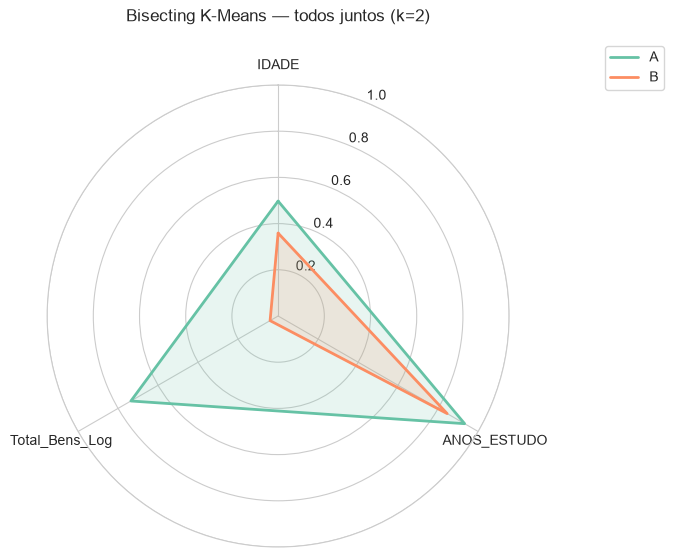

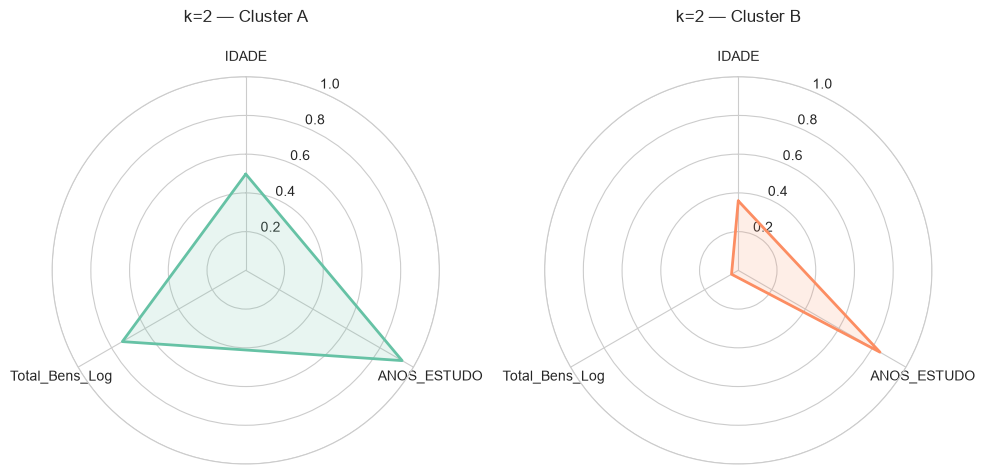

--- Bisecting K-Means, k=3 ---


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,155,51.9,15.2,900000.0
B,27,39.1,13.3,0.0
C,16,57.1,15.6,0.0


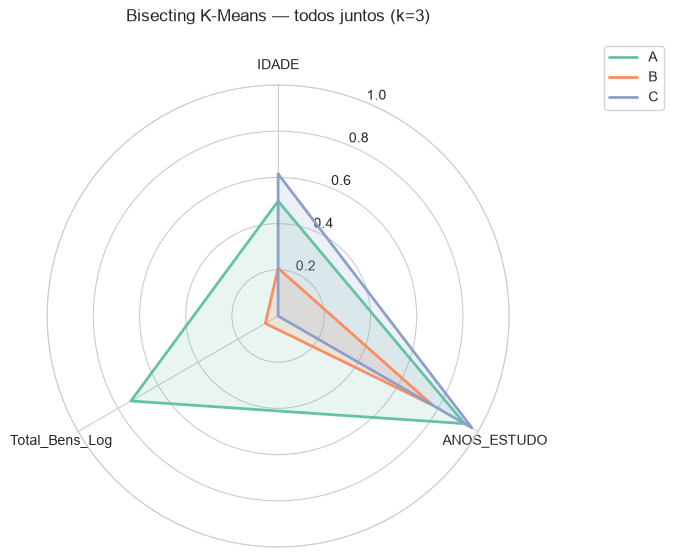

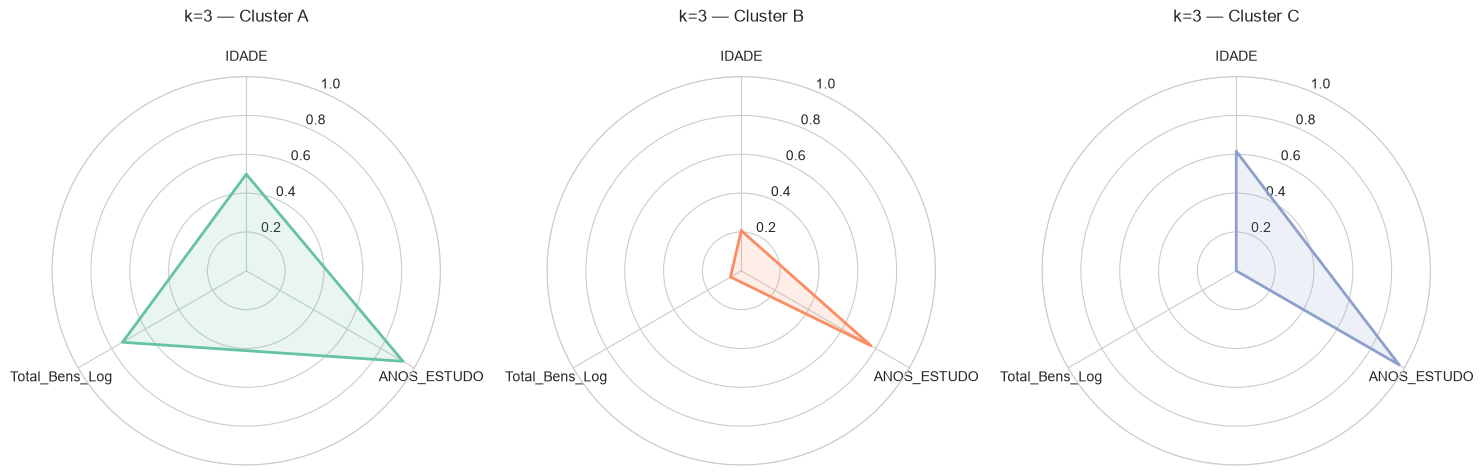

--- Bisecting K-Means, k=4 ---


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,84,43.1,15.0,583311.5
B,71,62.3,15.4,1216500.0
C,27,39.1,13.3,0.0
D,16,57.1,15.6,0.0


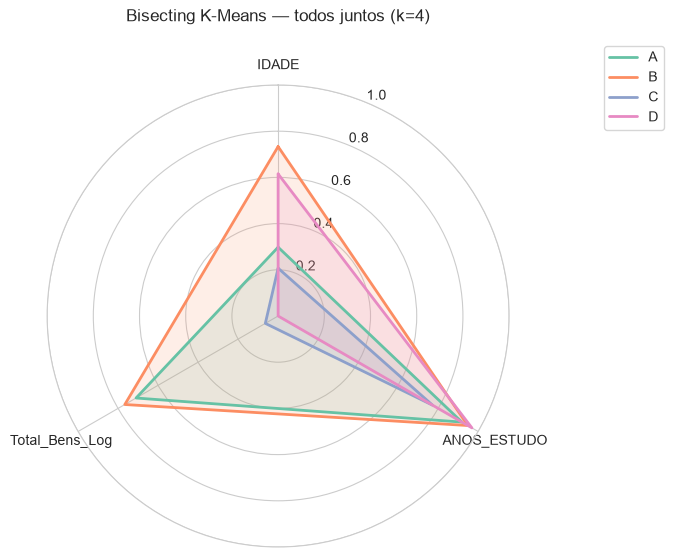

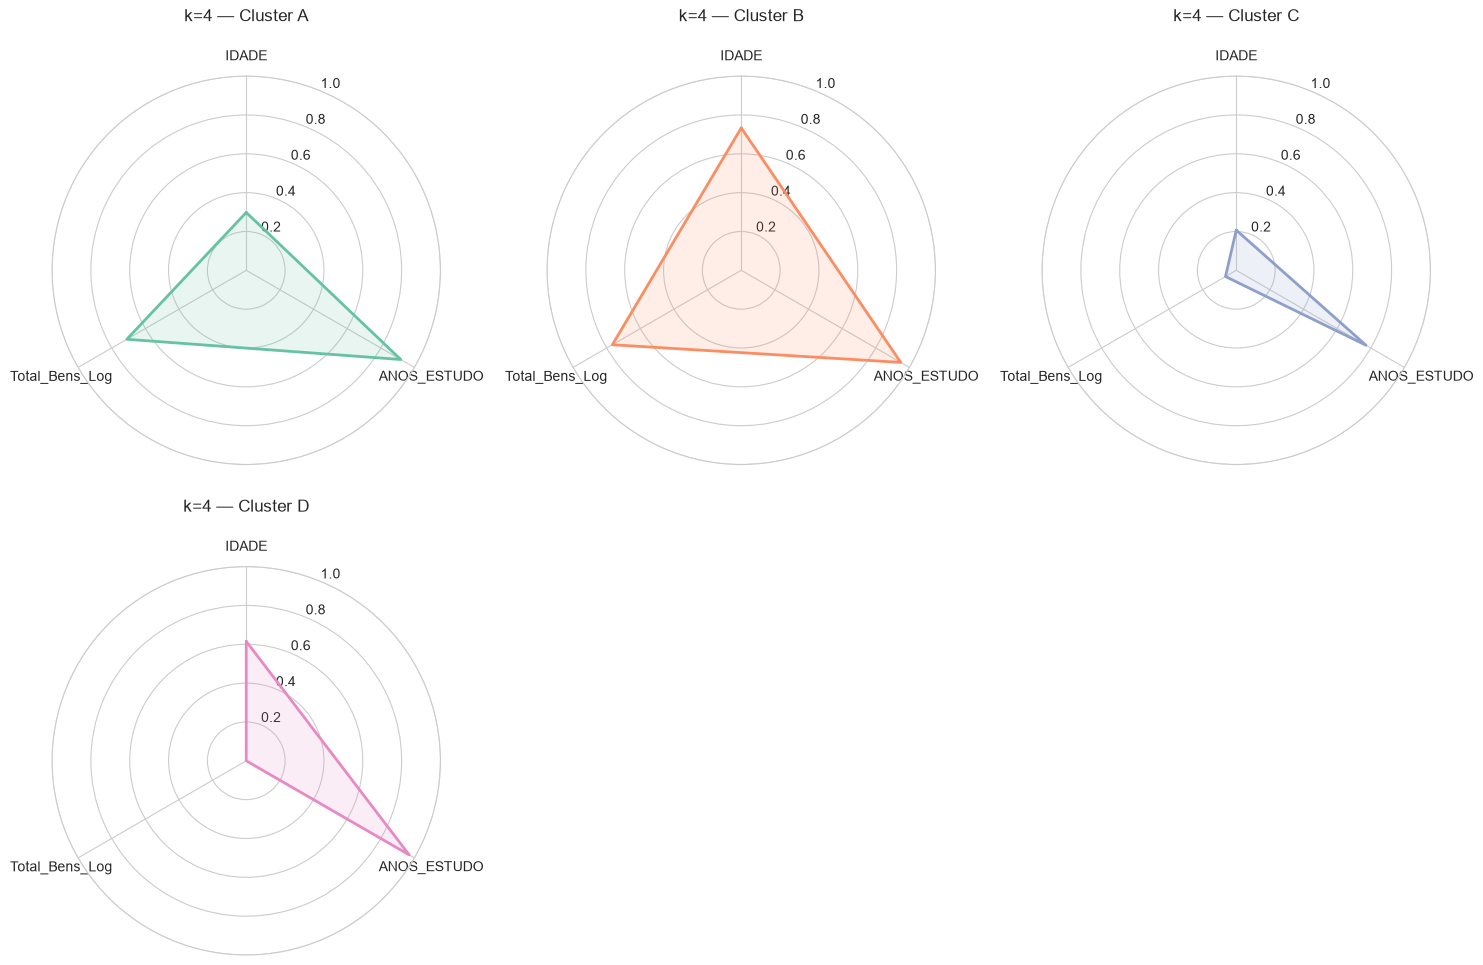

--- Bisecting K-Means, k=5 ---


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,84,43.1,15.0,583311.5
B,71,62.3,15.4,1216500.0
C,16,57.1,15.6,0.0
D,14,36.4,15.6,0.0
E,13,42.1,10.8,0.0


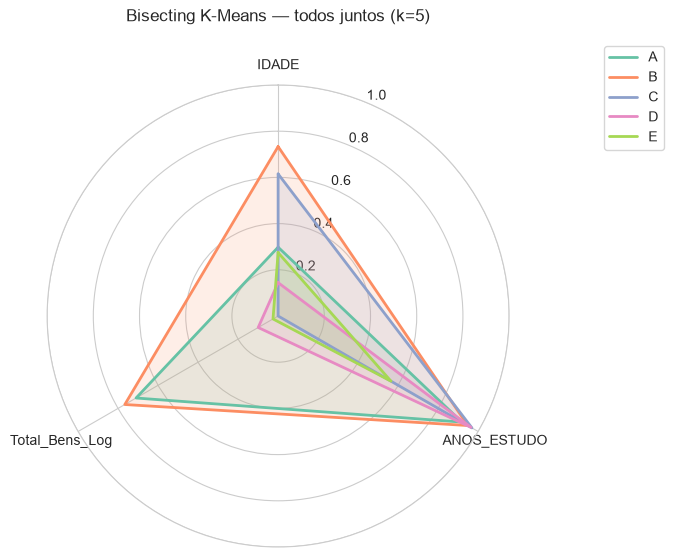

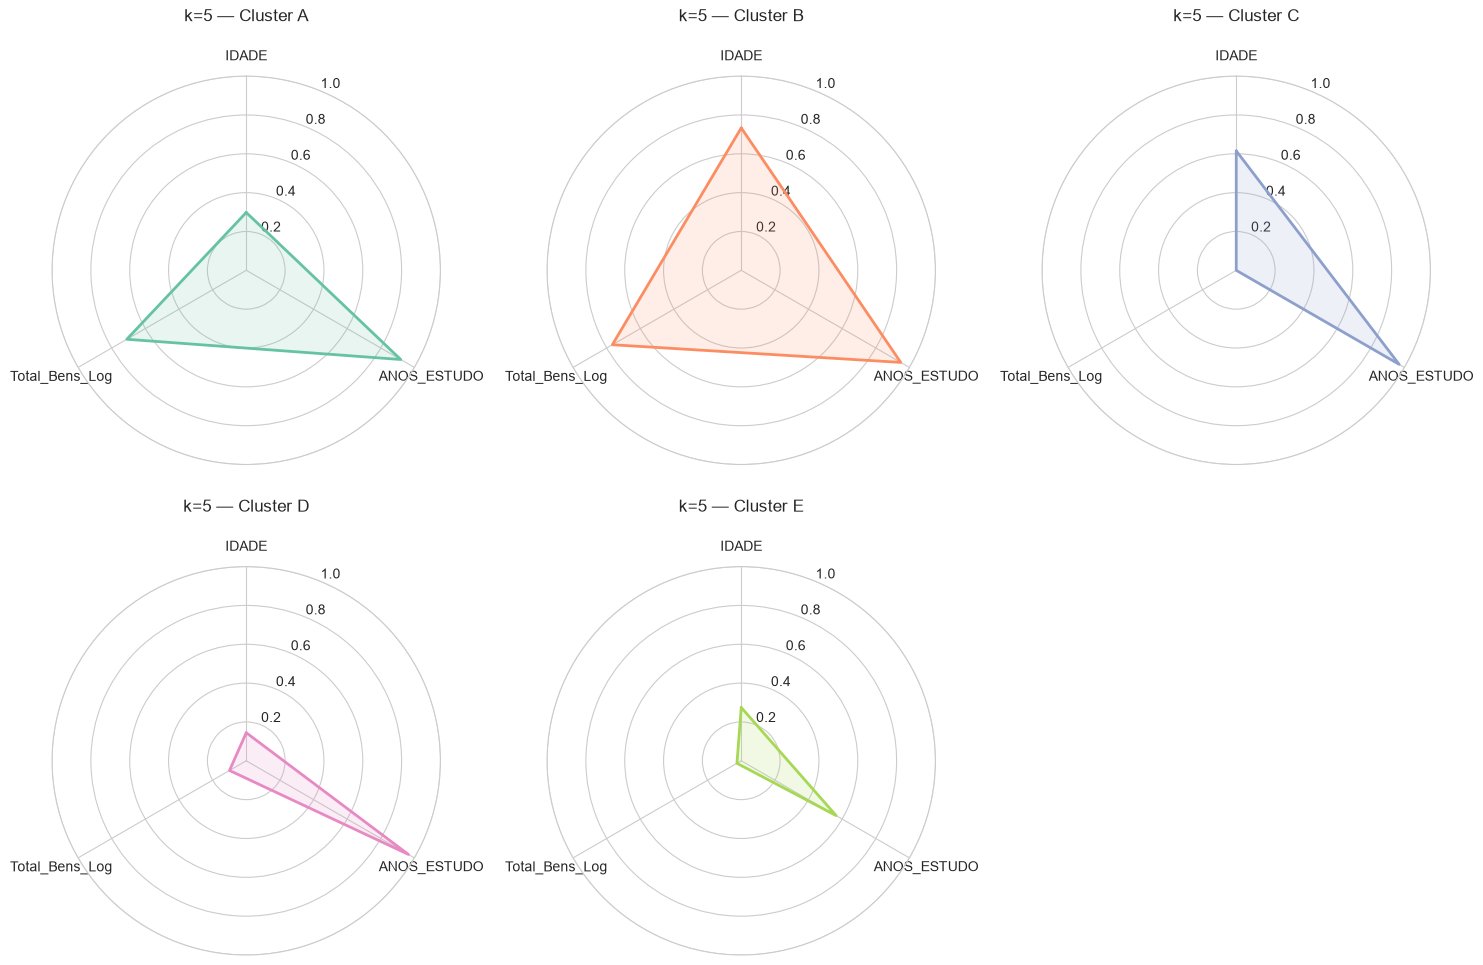

In [52]:
def clusters_bisecting_em_k(k):
    """Reconstrói a partição do Bisecting K-Means em k clusters, refazendo as divisões
    do histórico até esse ponto. Refazer o KMeans(n_clusters=2) é determinístico (mesma
    SEMENTE, mesmos dados de entrada), então reproduz exatamente a divisão já registrada —
    sem precisar guardar todos os índices no histórico."""
    clusters_no_k = {0: np.arange(X.shape[0])}
    for h in historico_bisecting:
        if h['k_resultante'] > k:
            break
        indices_pai = clusters_no_k.pop(h['pai_id'])
        km2 = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        clusters_no_k[h['filho_a_id']] = indices_pai[labels2 == 0]
        clusters_no_k[h['filho_b_id']] = indices_pai[labels2 == 1]

    # rótulos por ordem de tamanho (A = maior cluster, ...), mesma convenção usada em todo o notebook
    ids_por_tamanho = sorted(clusters_no_k, key=lambda cid: len(clusters_no_k[cid]), reverse=True)
    rotulos = np.empty(X.shape[0], dtype=object)
    for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
        rotulos[clusters_no_k[cid]] = letra
    return rotulos


for k in [2, 3, 4, 5]:
    rotulos_k = clusters_bisecting_em_k(k)
    clusters_k = sorted(set(rotulos_k))
    cores_k = dict(zip(clusters_k, sns.color_palette('Set2', n_colors=k)))

    print(f"--- Bisecting K-Means, k={k} ---")
    resumo_k = pd.DataFrame({
        'cluster': rotulos_k,
        'IDADE': df_cluster['IDADE'].values,
        'ANOS_ESTUDO': df_cluster['ANOS_ESTUDO'].values,
        'Total_Bens': df_cluster['Total_Bens'].values,
    }).groupby('cluster').agg(
        qtd_candidatos=('IDADE', 'count'),
        idade_media=('IDADE', 'mean'),
        anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
        patrimonio_mediano=('Total_Bens', 'median'),
    ).round(1)
    display(resumo_k)

    # "centróide" = média de cada cluster nas variáveis-driver padronizadas (ver explicação acima)
    centroides_k_norm = np.array([X[rotulos_k == cl].mean(axis=0) for cl in clusters_k])

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    plot_radar(ax, centroides_k_norm, colunas_driver, clusters_k, cores_k, f'Bisecting K-Means — todos juntos (k={k})')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    plt.show()

    ncols = min(k, 3)
    nrows = -(-k // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), subplot_kw=dict(polar=True))
    axes = axes.flatten() if k > 1 else [axes]
    for i, cl in enumerate(clusters_k):
        plot_radar(axes[i], [centroides_k_norm[i]], colunas_driver, [cl], cores_k, f'k={k} — Cluster {cl}')
    for j in range(len(clusters_k), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


### 5) Escolhendo k final e extraindo o resultado

Com base no que vimos acima — o gráfico de tamanho/inércia por nível, a árvore, e a exploração de `k=2` a `5` — fixamos um `k` final. Como agora o critério é a inércia média (não mais enviesado por tamanho), a curva de "quando parar" fica mais irregular — não existe mais um único cotovelo óbvio. Olhando os dados deste dataset, `k=3` continua sendo uma escolha razoável (o primeiro corte grande na curva de inércia, e a silhouette fica competitiva com o K-Means), mas vale reexaminar o gráfico da seção 2 e ajustar se quiser.


In [53]:
k_bisecting = 3  # ajuste conforme os gráficos das seções anteriores, se quiser

df_cluster['cluster_bisecting'] = clusters_bisecting_em_k(k_bisecting)
df_cluster['cluster_bisecting'].value_counts().sort_index()


cluster_bisecting
A    155
B     27
C     16
Name: count, dtype: int64

### 6) Comparando com o K-Means (Versão 2)

Silhouette — K-Means (V2, k=4):        0.443
Silhouette — Bisecting K-Means (k=3): 0.454


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster_bisecting,,,,
A,155,51.9,15.2,900000.0
B,27,39.1,13.3,0.0
C,16,57.1,15.6,0.0


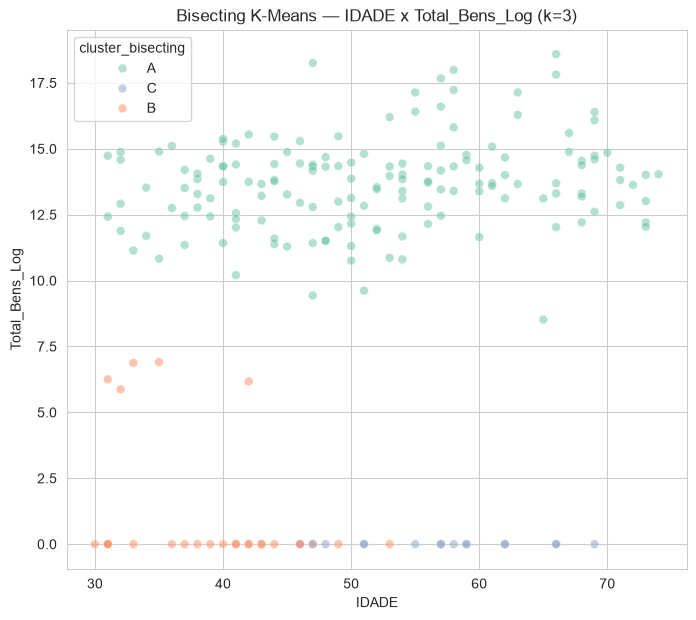

In [54]:
labels_bisecting = df_cluster['cluster_bisecting'].values
print(f"Silhouette — K-Means (V2, k={k_final}):        {silhouette_score(X, df_cluster['cluster']):.3f}")
print(f"Silhouette — Bisecting K-Means (k={k_bisecting}): {silhouette_score(X, labels_bisecting):.3f}")

resumo_bisecting = df_cluster.groupby('cluster_bisecting').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_bisecting)

clusters_bisecting_ordenados = sorted(df_cluster['cluster_bisecting'].unique())
cores_bisecting = dict(zip(clusters_bisecting_ordenados, sns.color_palette('Set2', n_colors=len(clusters_bisecting_ordenados))))

plt.figure(figsize=(8, 7))
sns.scatterplot(data=df_cluster, x='IDADE', y='Total_Bens_Log', hue='cluster_bisecting', palette=cores_bisecting, alpha=0.5, s=40)
plt.title(f'Bisecting K-Means — IDADE x Total_Bens_Log (k={k_bisecting})')
plt.show()

**Interpretação:** compare o `resumo_bisecting` com o `resumo_driver` do K-Means e a silhouette dos dois. Se os grupos ficarem parecidos, é um bom sinal de que a estrutura é real (dois algoritmos diferentes concordando); se ficarem bem diferentes, vale a pena entender por quê — o K-Means busca uma solução global pra todo o `k` de uma vez, enquanto o Bisecting constrói de forma incremental, e pode ficar "preso" a decisões tomadas em níveis anteriores.

Agora aplicamos de verdade o mesmo kit de nomeação da Parte 1 (ficha técnica, heatmap de desvio, rascunho automático) para os clusters do Bisecting — e ampliamos a leitura demográfica com partido e UF, que a Parte 1 não cobriu.


### 7) Ficha técnica por cluster (Bisecting K-Means)


In [55]:
ficha_bisecting = df_cluster.groupby('cluster_bisecting').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_medio=('Total_Bens', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
ficha_bisecting['pct_do_total'] = (ficha_bisecting['qtd'] / ficha_bisecting['qtd'].sum() * 100).round(1)
ficha_bisecting['pct_sem_bens'] = df_cluster.groupby('cluster_bisecting')['Total_Bens'].apply(
    lambda s: (s == 0).mean() * 100
).round(1)

for col in colunas_perfil:
    ficha_bisecting[f'{col}_predominante'] = df_cluster.groupby('cluster_bisecting')[col].agg(lambda s: s.mode().iat[0])
    ficha_bisecting[f'{col}_pct'] = df_cluster.groupby('cluster_bisecting')[col].apply(
        lambda s: (s == s.mode().iat[0]).mean() * 100
    ).round(1)

ficha_bisecting


,qtd,idade_media,anos_estudo_medio,patrimonio_medio,patrimonio_mediano,pct_do_total,pct_sem_bens,DS_GENERO_predominante,DS_GENERO_pct,DS_COR_RACA_predominante,DS_COR_RACA_pct,DS_ESTADO_CIVIL_predominante,DS_ESTADO_CIVIL_pct
cluster_bisecting,,,,,,,,,,,,,
A,155,51.9,15.2,4561619.8,900000.0,78.3,0.0,MASCULINO,84.5,BRANCA,65.2,CASADO(A),71.0
B,27,39.1,13.3,123.0,0.0,13.6,81.5,MASCULINO,70.4,BRANCA,33.3,SOLTEIRO(A),70.4
C,16,57.1,15.6,0.0,0.0,8.1,100.0,MASCULINO,87.5,PARDA,50.0,SOLTEIRO(A),37.5


### 8) O que destaca cada cluster (desvio em relação à média geral)


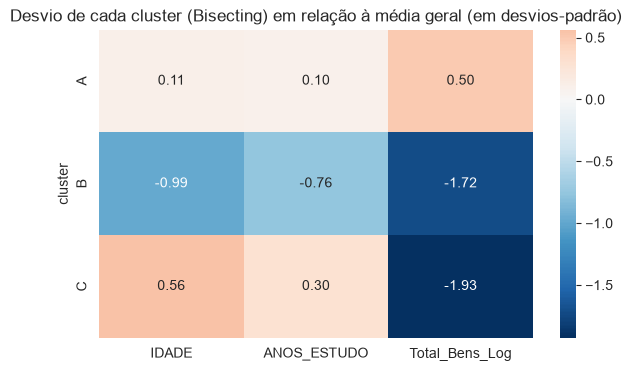

In [56]:
medias_cluster_bisecting = df_cluster.groupby('cluster_bisecting')[colunas_driver].mean()
zscore_cluster_bisecting = (medias_cluster_bisecting - medias_gerais) / desvios_gerais

plt.figure(figsize=(7, 1 + k_bisecting))
sns.heatmap(zscore_cluster_bisecting, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Desvio de cada cluster (Bisecting) em relação à média geral (em desvios-padrão)')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()


In [63]:
NOMES_CLUSTER_BISECTING = {
    'A': 'Abastados',
    'B': 'Jovens',
    'C': 'Sem bens e alta escolaridade',
}
df_cluster['nome_cluster_bisecting'] = df_cluster['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)
df_cluster[['cluster_bisecting', 'nome_cluster_bisecting']].value_counts().sort_index()

cluster_bisecting  nome_cluster_bisecting      
A                  Abastados                       155
B                  Jovens                           27
C                  Sem bens e alta escolaridade     16
Name: count, dtype: int64

In [ ]:
nomes_bisecting_ordenados = [NOMES_CLUSTER_BISECTING[c] for c in clusters_bisecting_ordenados]
cores_nome_bisecting = {NOMES_CLUSTER_BISECTING[c]: cor for c, cor in cores_bisecting.items()}


### 9) Composição demográfica: gênero, cor/raça, estado civil


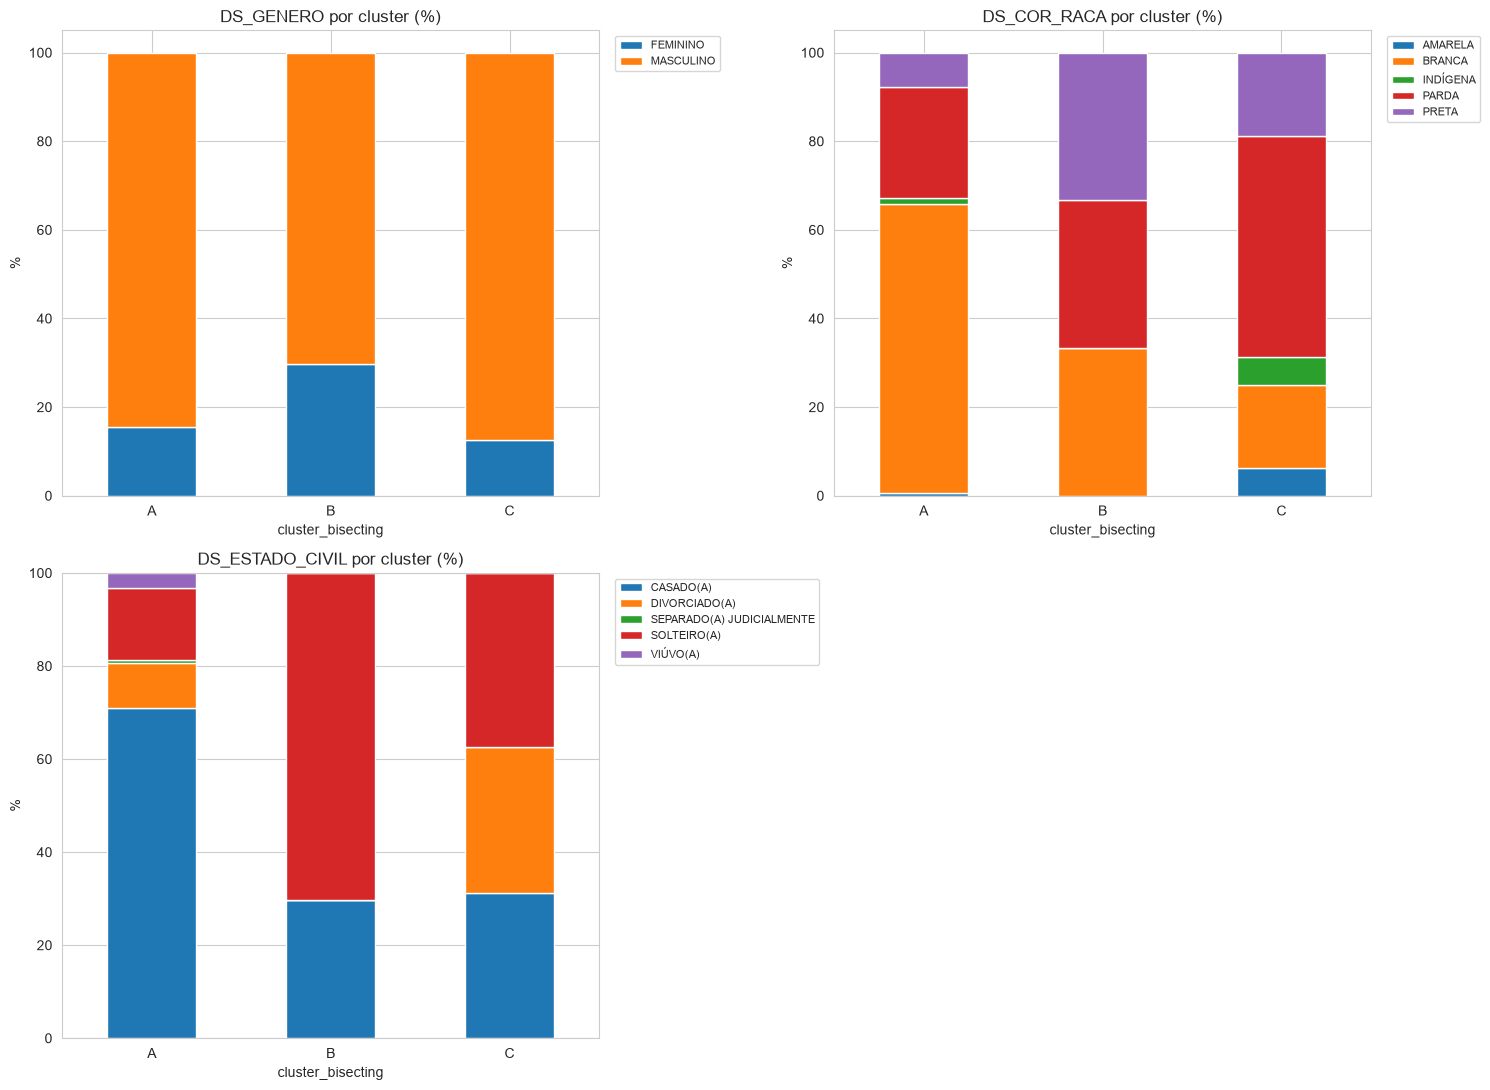

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    pd.crosstab(df_cluster['nome_cluster_bisecting'], df_cluster[col], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=axes[i]
    )
    axes[i].set_title(f'{col} por cluster (%)')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Direção inversa: onde cada grupo demográfico está distribuído entre os clusters

Até aqui perguntamos "dentro do cluster X, qual a composição por gênero/cor-raça/estado civil?". Agora invertemos: **de todos os candidatos de um determinado grupo, em qual cluster eles estão?** Mesma tabela de contingência, só trocando o que normaliza — mesma lógica já usada na Parte 1.


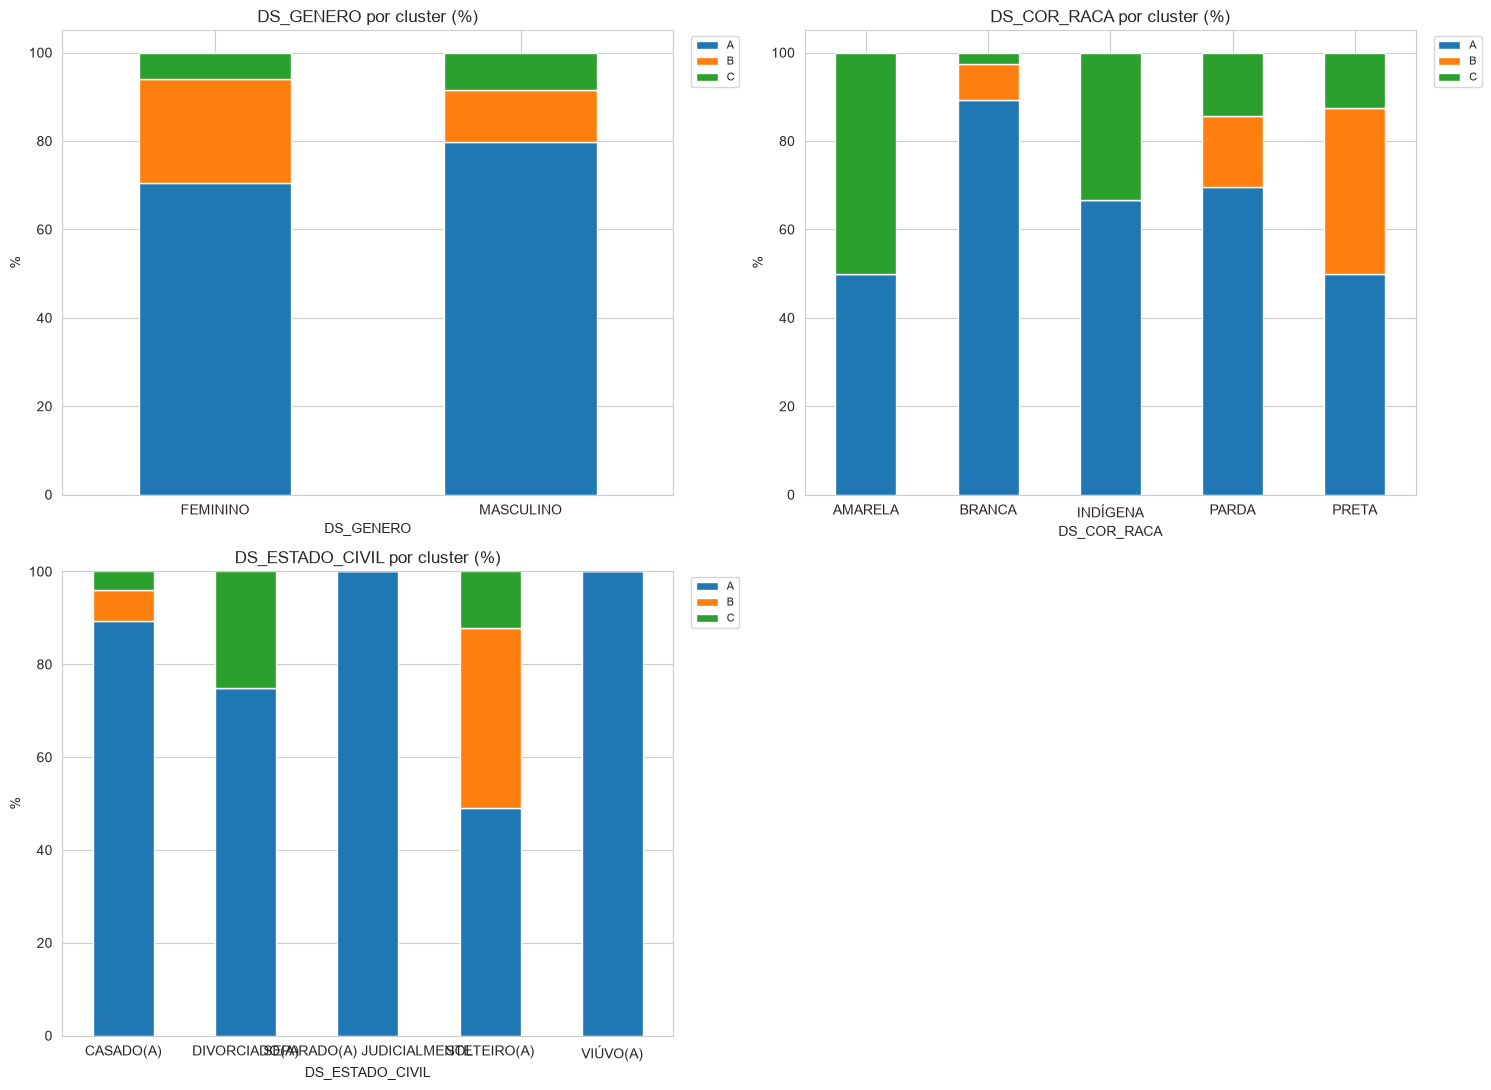

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df_cluster[col], df_cluster['nome_cluster_bisecting'], normalize='index').mul(100)
    tabela = tabela[nomes_bisecting_ordenados]  # garante a mesma ordem de colunas de cores_nome_bisecting
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_nome_bisecting[c] for c in tabela.columns])
    axes[i].set_title(f'Distribuição entre clusters, por categoria de {col} (%)')
    axes[i].set_ylabel('%')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 10) Partidos: quais legendas dominam cada cluster

A Parte 1 não olhou partido — mas como boa parte do que diferencia os clusters aqui é "declarou patrimônio ou não", vale ver se isso também aparece na legenda: candidaturas de partidos pequenos costumam ser mais simbólicas, com menos estrutura (e menos bens declarados) por trás.


In [58]:
for nome in nomes_bisecting_ordenados:
    sub = df_cluster[df_cluster['nome_cluster_bisecting'] == nome]
    top5 = (sub['SG_PARTIDO'].value_counts(normalize=True) * 100).round(1).head(5)
    print(f"{nome} ({len(sub)} candidatos) — partidos mais frequentes:")
    for partido, pct in top5.items():
        print(f"  {partido}: {pct:.1f}%")
    print()


Cluster A (155 candidatos) — partidos mais frequentes:
  PSD: 8.4%
  PSTU: 7.7%
  PL: 7.7%
  PT: 7.7%
  PSDB: 5.8%

Cluster B (27 candidatos) — partidos mais frequentes:
  PCO: 33.3%
  UP: 25.9%
  MISSÃO: 11.1%
  PCB: 7.4%
  AGIR: 7.4%

Cluster C (16 candidatos) — partidos mais frequentes:
  PCO: 25.0%
  AGIR: 12.5%
  DEMOCRATA: 12.5%
  DC: 12.5%
  PSTU: 12.5%



### 11) Existe um padrão regional?

Esta seção só roda na visão **Brasil** (quando `UF = None`) — mesma lógica da Parte 1. Com 27 UFs, uma tabela crua de contingência é difícil de escanear — preferimos duas pizzas: uma olhando de dentro de cada cluster ("desse grupo, de onde vêm os candidatos?"), outra de dentro de cada UF ("nesse estado, qual a mistura de clusters?").


In [59]:
def contagem_top_n(serie, top_n=8, rotulo_outros='Outros'):
    """Série de contagens com só as `top_n` categorias mais frequentes; o resto vira uma
    única fatia `rotulo_outros—pra pizza não virar um mosaico de fatias minúsculas
    (relevante aqui: SG_UF tem 27 valores possíveis)."""
    contagem = serie.value_counts()
    if len(contagem) <= top_n:
        return contagem
    principais = contagem.head(top_n).copy()
    resto = contagem.iloc[top_n:].sum()
    if resto > 0:
        principais[rotulo_outros] = resto
    return principais


if UF is None:
    fig, axes = plt.subplots(1, len(nomes_bisecting_ordenados), figsize=(5 * len(nomes_bisecting_ordenados), 5))
    for ax, nome in zip(axes, nomes_bisecting_ordenados):
        sub = df_cluster[df_cluster['nome_cluster_bisecting'] == nome]
        contagem = contagem_top_n(sub['SG_UF'], top_n=8)
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 8})
        ax.set_title(f'{nome} ({len(sub)} candidatos)')
    plt.suptitle('UF de candidatura dentro de cada cluster (top 8 + Outros)', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")


cluster_bisecting,A,B,C
SG_UF,,,
AC,83.3,0.0,16.7
AL,75.0,0.0,25.0
AM,85.7,0.0,14.3
AP,60.0,20.0,20.0
BA,100.0,0.0,0.0
CE,66.7,33.3,0.0
DF,100.0,0.0,0.0
ES,80.0,20.0,0.0
GO,100.0,0.0,0.0


In [ ]:
if UF is None:
    ufs_ordenadas = sorted(df_cluster['SG_UF'].unique())
    ncols = 6
    nrows = -(-len(ufs_ordenadas) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows))
    axes = axes.flatten()

    for ax, uf in zip(axes, ufs_ordenadas):
        sub = df_cluster[df_cluster['SG_UF'] == uf]
        contagem = sub['nome_cluster_bisecting'].value_counts()
        cores_fatias = [cores_nome_bisecting[nome] for nome in contagem.index]
        ax.pie(contagem, labels=None, autopct=lambda p: f'{p:.0f}%' if p > 0 else '',
               colors=cores_fatias, textprops={'fontsize': 7})
        ax.set_title(f'{uf} ({len(sub)})', fontsize=10)

    for ax in axes[len(ufs_ordenadas):]:
        ax.axis('off')

    handles = [plt.Rectangle((0, 0), 1, 1, color=cores_nome_bisecting[nome]) for nome in nomes_bisecting_ordenados]
    fig.legend(handles, nomes_bisecting_ordenados, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize=11)
    plt.suptitle('Composição de cluster dentro de cada UF', y=1.06)
    plt.tight_layout()
    plt.show()
else:
    print(f"UF = {UF!r} — seção não se aplica (dados já filtrados para uma única UF).")


### 12) Rascunho automático — editem à vontade


In [60]:
for cl in clusters_bisecting_ordenados:
    linha = ficha_bisecting.loc[cl]
    print(f"Cluster {cl}  ({linha['qtd']:.0f} candidatos, {linha['pct_do_total']:.0f}% do total)")
    print(f"  Idade média: {linha['idade_media']:.0f} anos | Escolaridade média: {linha['anos_estudo_medio']:.0f} anos de estudo")
    print(f"  Patrimônio mediano: R$ {linha['patrimonio_mediano']:,.0f} | {linha['pct_sem_bens']:.0f}% declaram patrimônio zero")
    for col in colunas_perfil:
        print(f"  Predominância em {col}: {linha[f'{col}_predominante']} ({linha[f'{col}_pct']:.0f}%)")
    print(f"  >> Nome sugerido: _______________________")
    print()


Cluster A  (155 candidatos, 78% do total)
  Idade média: 52 anos | Escolaridade média: 15 anos de estudo
  Patrimônio mediano: R$ 900,000 | 0% declaram patrimônio zero
  Predominância em DS_GENERO: MASCULINO (84%)
  Predominância em DS_COR_RACA: BRANCA (65%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (71%)
  >> Nome sugerido: _______________________

Cluster B  (27 candidatos, 14% do total)
  Idade média: 39 anos | Escolaridade média: 13 anos de estudo
  Patrimônio mediano: R$ 0 | 82% declaram patrimônio zero
  Predominância em DS_GENERO: MASCULINO (70%)
  Predominância em DS_COR_RACA: BRANCA (33%)
  Predominância em DS_ESTADO_CIVIL: SOLTEIRO(A) (70%)
  >> Nome sugerido: _______________________

Cluster C  (16 candidatos, 8% do total)
  Idade média: 57 anos | Escolaridade média: 16 anos de estudo
  Patrimônio mediano: R$ 0 | 100% declaram patrimônio zero
  Predominância em DS_GENERO: MASCULINO (88%)
  Predominância em DS_COR_RACA: PARDA (50%)
  Predominância em DS_ESTADO_CIVIL: SOLT

### Nomes finais dos clusters (Bisecting K-Means, k=3)

A partir da ficha técnica e das composições acima, os três clusters se leem assim:

- **Cluster A** (155 candidatos, 78% do total): idade média 52 anos, escolaridade média 15 anos, **todos** com algum patrimônio declarado (mediano R$ 900 mil), maioria de partidos de peso (PSD, PT, PL, PSDB...). → **Abastados**.
- **Cluster B** (27 candidatos, 14% do total): o grupo mais jovem, de longe — idade média 39 anos, contra 52 (A) e 57 (C) — 82% sem nenhum patrimônio declarado, escolaridade um pouco menor, concentrado em partidos pequenos de esquerda (PCO, UP...). → **Jovens**.
- **Cluster C** (16 candidatos, 8% do total): **100%** sem nenhum patrimônio declarado, a maior escolaridade média dos três (16 anos), e também o grupo mais velho (57 anos), também concentrado em partidos pequenos. → **Sem bens e alta escolaridade**.

Concordamos com a leitura proposta: os três nomes são sustentados pelos números. Duas ressalvas que valem registrar:

1. **"Abastados" é 78% da base, não uma elite isolada.** O corte que separa A de B/C é, na prática, "declarou algum patrimônio" vs. "declarou zero" — não um pequeno grupo de super-ricos destacado do resto. Boa parte disso é reflexo do próprio sistema partidário: candidaturas de partidos pequenos e/ou mais simbólicas costumam vir com patrimônio zerado, então "ter bens" acaba correlacionado com "ser de um partido estabelecido", mais do que com riqueza pessoal isoladamente.
2. **O Cluster C também é o mais velho dos três** (57 anos, contra 52 em A e 39 em B) — o nome escolhido foca em escolaridade e patrimônio, mas a idade é outro traço forte que vale mencionar ao descrever esse grupo.


In [61]:
# nomes já aplicados mais acima (logo depois da seção 8), reaproveitados em toda a análise
# demográfica/partidária/regional desta parte — aqui só o recap final:
df_cluster[['cluster_bisecting', 'nome_cluster_bisecting']].value_counts().sort_index()


cluster_bisecting  nome_cluster_bisecting      
A                  Abastados                       155
B                  Jovens                           27
C                  Sem bens e alta escolaridade     16
Name: count, dtype: int64

---
## Fechamento e próximos passos

Duas famílias de algoritmo até aqui:

- **K-Means (Parte 1)**, em duas rodadas — mostrando o efeito de tratar uma variável ordinal como intervalar, e de usar mais de uma métrica pra escolher `k`.
- **Bisecting K-Means (Parte 2)** — construção incremental e visual, com uma árvore mostrando a ordem das divisões, um critério de parada baseado em quando parar de dividir clusters grandes, e os 3 clusters finais (k=3) nomeados: **Abastados**, **Jovens** e **Sem bens e alta escolaridade**.

Continua em `02_clusterizacao_outros.ipynb`: **DBSCAN** e **clusterização hierárquica**, reaproveitando a mesma base e a mesma pergunta de negócio.